## All graphs necessary for the project (+ more).

First, some import.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---- Global plotting/style configuration (paper-wide) ----
PLOT_THEME = {"style": "whitegrid", "context": "paper"}
PLOT_RCPARAMS = {
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "legend.frameon" : True
}

QAOA_VARIANTS = ["multiangle", "vanilla"]
QAOA_VARIANT_LABELS = {
    "multiangle": "Multiangle",
    "vanilla": "Vanilla",
}
QAOA_VARIANT_COLORS = {
    "multiangle": "#C23B3B",
    "vanilla": "#2E6FBB",
}
QAOA_VARIANT_LINESTYLES = {
    "multiangle": "--",
    "vanilla": "-",
}

# Shared palettes for repeated plots
WARMSTART_RESULT_PALETTE = {
    "Improved %": "#2ca02c",
    "Same %": "#1f77b4",
    "Worsened %": "#d62728",
}
HUE_PALETTES = {
    "hamming_dist": "magma",
}

# Shared constants
DEFUALT_COLUMN_FIGSIZE = (3.5,2.6)
OPTIMAL_LINE_COLOR = "red"
DEFAULT_QAOA_PAIR_FIGSIZE = (12, 6)

sns.set_theme(**PLOT_THEME)
plt.rcParams.update(PLOT_RCPARAMS)

from src.qaoa.models.MaxCutProblem import MaxCutProblem
from src.qaoa.models.solver import MinVertexCoverSolver
import numpy as np
import json
import sqlite3
import hashlib
import pickle
import base64


In [33]:
""""""
conn = sqlite3.connect('qruns_final.db')
cur = conn.cursor()

#print(cur.execute("PRAGMA quick_check;").fetchall())      # faster
#print(cur.execute("PRAGMA integrity_check;").fetchall())  # more thorough
qruns_df = pd.read_sql_query("SELECT * FROM runs", conn)
qruns_df.to_csv('qruns_export.csv', index=False)

conn.close()
"""
conn = sqlite3.connect('qruns_large_uniform.db')
qruns_df2 = pd.read_sql_query("SELECT * FROM runs", conn)
conn.close()

conn = sqlite3.connect('qruns_ws_lg.db') #read from quantum runs warm stand lagrange 
df_lagrange = pd.read_sql_query("SELECT * FROM runs", conn)
conn.close()

qruns_df = pd.concat([qruns_df, qruns_df2,df_lagrange])"""
print(f"Total number of runs in database: {len(qruns_df)}")
no_artefact = qruns_df[qruns_df['artefact_path'].isna()]
print('Amount of null rows: ', no_artefact.tail())
results = qruns_df["artefact_path"].copy()


solver_cache = {}
def get_solver(graph):
    key = graph['__bytes_b64__']  # stable serialized representation
    if key not in solver_cache:
        g = pickle.loads(base64.b64decode(key))
        solver_cache[key] = MinVertexCoverSolver(g, 'mvc', lagrangian=2)
    return solver_cache[key]

def bitstring_value_updater_cached(graph, bitstring):
    solver = get_solver(graph)
    return solver.evaluate_bitstring([round(x) for x in bitstring])



pd.set_option('display.max_colwidth', None)
print(qruns_df["artefact_path"].head(10).to_string(index=False))
pd.reset_option('display.max_colwidth')
qruns_df = qruns_df[qruns_df['artefact_path'].notna()]

results = pd.DataFrame(qruns_df['artefact_path'].map(json.loads).tolist())
#results = results[~((results['qaoa_variant'] == 'vanilla') & (results['depth'].isin([10, 12,14])) & (results['lagrangian_multiplier'] == 2)& (results['graph_size'] != 6)& (results['warm_start'] == False))]
#results = pd.concat([results, rerun_df], ignore_index=True)

results['graph identifier'] = results['graph_size'].astype(int).astype(str) + '-d' + results['graph_degree'].astype(int).astype(str)
results['run_identifier'] = results['qaoa_variant'] + results['depth'].apply(str) +'warm start: '+ results['warm_start'].apply(str) + ' hamming dist: '+  results['hamming_dist'].apply(str) + " penalty factor: " + results['lagrangian_multiplier'].apply(str)

mask_lagrange = results['lagrangian_multiplier'] != 2
subset = results.loc[mask_lagrange, ['graph', 'quantum_solution']]

results.loc[mask_lagrange, 'quantum_obj_value'] = [
    bitstring_value_updater_cached(graph, bitstring)
    for graph, bitstring in zip(subset['graph'], subset['quantum_solution'])
]

mask_warm = results['warm_start']
subset = results.loc[mask_warm, ['graph', 'hamming_string']]

results.loc[mask_warm, 'hamming_obj_func'] = [
    bitstring_value_updater_cached(graph, bitstring)
    for graph, bitstring in zip(subset['graph'], subset['hamming_string'])
]

#needs update after lagrange update
results['ratio'] = results['classic_value']/results['quantum_obj_value']

#results['ratio'] = 1/results['ratio']

save_images = True
results.columns


Total number of runs in database: 93999
Amount of null rows:             id                                             params    state  \
71467  103409  {"backend_mode": "statevector", "qaoa_variant"...  running   
71502  103444  {"backend_mode": "statevector", "qaoa_variant"...  running   
71505  103447  {"backend_mode": "statevector", "qaoa_variant"...  running   
71507  103449  {"backend_mode": "statevector", "qaoa_variant"...  running   
71567  103509  {"backend_mode": "statevector", "qaoa_variant"...  running   

       node           started_at finished_at artefact_path error_msg  
71467  None  2026-04-27 13:01:16        None          None      None  
71502  None  2026-04-27 13:05:43        None          None      None  
71505  None  2026-04-27 13:05:58        None          None      None  
71507  None  2026-04-27 13:06:06        None          None      None  
71567  None  2026-04-27 13:13:45        None          None      None  
 {"graph_size": 10, "backend_mode": "statevector"

Index(['graph_size', 'backend_mode', 'param_initialization', 'qaoa_variant',
       'optimizer', 'warm_start', 'depth', 'problem_type', 'amount_shots',
       'max_tol', 'lagrangian_multiplier', 'time_elapsed',
       'quantum_func_evals', 'ratio', 'quantum_solution', 'quantum_obj_value',
       'classic_solution', 'classic_value', 'final_params',
       'percent_measure_optimal', 'hamming_dist', 'hamming_string',
       'hamming_obj_func', 'epsilon', 'final_expectation_value', 'feasible',
       'graph_degree', 'graph', 'graph_weighted', 'graph identifier',
       'run_identifier'],
      dtype='object')

In [3]:
""""""
conn = sqlite3.connect('qruns_10k.db')
cur = conn.cursor()

print(cur.execute("PRAGMA quick_check;").fetchall())      # faster
print(cur.execute("PRAGMA integrity_check;").fetchall())  # more thorough

rerun_df = pd.read_sql_query("SELECT * FROM runs", conn)

conn.close()

conn = sqlite3.connect('qruns_depth14.db')
cur = conn.cursor()


rerun_df_14 = pd.read_sql_query("SELECT * FROM runs", conn)

conn.close()
rerun_df = pd.concat([rerun_df, rerun_df_14])
rerun_df = pd.DataFrame(rerun_df['artefact_path'].map(json.loads).tolist())
print(len(rerun_df))
rerun_df['ratio'] = 1/rerun_df['ratio']

[('ok',)]
[('ok',)]
6000


In [4]:
display(rerun_df.head(5))

,graph_size,backend_mode,param_initialization,qaoa_variant,optimizer,warm_start,depth,problem_type,amount_shots,max_tol,...,hamming_dist,hamming_string,hamming_obj_func,epsilon,final_expectation_value,feasible,graph_degree,graph,graph_weighted,maxiter
0,8,statevector,uniform,vanilla,COBYLA,False,14,minvertexcover,1024,0.0001,...,0,None,None,0.3,3.959979,True,3,{'__bytes_b64__': 'gASVQQEAAAAAAACMCXJ1c3R3b3J...,True,10000.0
1,8,statevector,uniform,vanilla,COBYLA,False,14,minvertexcover,1024,0.0001,...,0,None,None,0.3,4.133324,True,3,{'__bytes_b64__': 'gASVQQEAAAAAAACMCXJ1c3R3b3J...,True,10000.0
2,8,statevector,uniform,vanilla,COBYLA,False,14,minvertexcover,1024,0.0001,...,0,None,None,0.3,7.102542,True,3,{'__bytes_b64__': 'gASVQQEAAAAAAACMCXJ1c3R3b3J...,True,10000.0
3,8,statevector,uniform,vanilla,COBYLA,False,14,minvertexcover,1024,0.0001,...,0,None,None,0.3,4.476617,True,3,{'__bytes_b64__': 'gASVQQEAAAAAAACMCXJ1c3R3b3J...,True,10000.0
4,8,statevector,uniform,vanilla,COBYLA,False,14,minvertexcover,1024,0.0001,...,0,None,None,0.3,3.814473,True,3,{'__bytes_b64__': 'gASVQQEAAAAAAACMCXJ1c3R3b3J...,True,10000.0


In [5]:

# Assuming rerun_df is already defined from previous cells
grouped_ratio = rerun_df.groupby('graph_size')['ratio'].mean()
print(grouped_ratio)

graph_size
8     0.891274
10    0.915557
12    0.926215
Name: ratio, dtype: float64


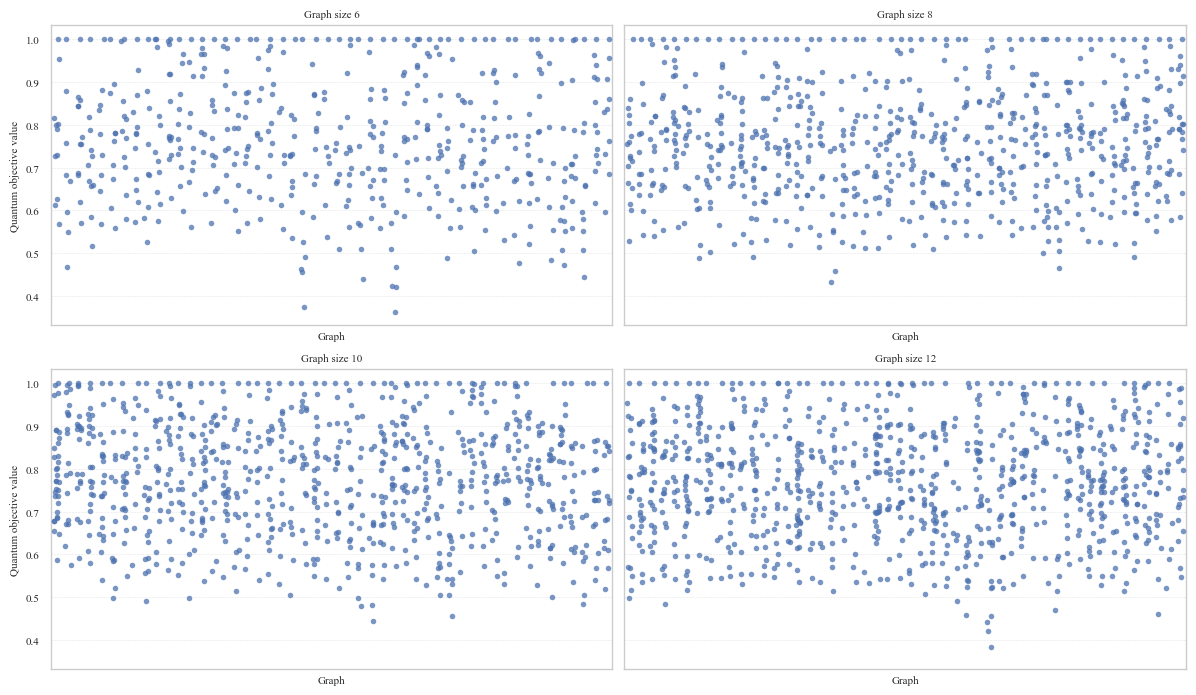

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Create a copy of results to work with
df = results[(results['warm_start']==False) &( results['lagrangian_multiplier'] ==2)].copy()

df_unique = (
    df[
        [
            'graph_size',
            'graph',
            'quantum_solution',
            'quantum_obj_value',
            'feasible',
            'ratio',
            'qaoa_variant'
        ]
    ]
    .copy()
)
df_unique = df_unique[df_unique['feasible']]
df_unique = df_unique[df_unique['qaoa_variant']=='vanilla']
# Stable identifier for each graph
df_unique['graph_identifier'] = df_unique['graph'].apply(
    lambda g: g['__bytes_b64__']
)

df_unique.drop(columns=['graph'], inplace=True)

# Convert quantum solution to readable string
df_unique['quantum_solution_str'] = df_unique['quantum_solution'].apply(
    lambda sol: ''.join(str(int(round(x))) for x in sol)
)

# Drop duplicate solutions/objective values per graph, not globally
df_unique = df_unique.drop_duplicates(
    subset=[
        'graph_size',
        'graph_identifier',
        'quantum_solution_str',
        'quantum_obj_value'
    ]
)

# Replace ugly base64 graph identifiers with compact graph numbers per graph size
df_unique['graph_id'] = (
    df_unique
    .groupby('graph_size')['graph_identifier']
    .transform(lambda s: pd.factorize(s)[0] + 1)
)

df_unique['graph_id'] = df_unique['graph_id'].astype(str)

# Make one subplot per graph size
graph_sizes = sorted(df_unique['graph_size'].unique())

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12, 7),
    sharey=True
)

axes = axes.flatten()

for ax, size in zip(axes, graph_sizes):
    df_size = df_unique[df_unique['graph_size'] == size].copy()

    sns.stripplot(
        data=df_size,
        x='graph_id',
        y='ratio',
        ax=ax,
        jitter=0.25,
        alpha=0.75,
        size=4
    )

    ax.set_title(f'Graph size {size}')
    ax.set_xlabel('Graph')
    ax.set_ylabel('Quantum objective value')
    ax.grid(True, axis='y', linestyle='--', linewidth=0.4, alpha=0.5)

    # Optional: avoid overcrowded x labels
    if df_size['graph_id'].nunique() > 20:
        ax.set_xticks([])

# Hide unused axes if fewer than 4 graph sizes
for ax in axes[len(graph_sizes):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [28]:
import networkx as nx
from collections import Counter, defaultdict

def nx_graph_from_dict(graph_dict):
    if not isinstance(graph_dict, dict):
        raise TypeError("Expected a dict with '__bytes_b64__'")
    b64 = graph_dict.get("__bytes_b64__")
    if not isinstance(b64, str):
        raise ValueError("Missing __bytes_b64__ in graph dict")
    obj = pickle.loads(base64.b64decode(b64))
    if isinstance(obj, nx.Graph):
        return obj
    if hasattr(obj, "to_networkx"):
        return obj.to_networkx()
    if hasattr(obj, "edges") and hasattr(obj, "nodes"):
        G = nx.Graph()
        G.add_nodes_from(obj.nodes())
        G.add_edges_from(obj.edges())
        return G
    raise ValueError("Cannot convert graph object to networkx Graph")

def eigenvalue_multiplicities(G):
    A = nx.to_numpy_array(G, dtype=float)
    eigs = np.linalg.eigvalsh(A)
    eigs_rounded = np.round(eigs, 8)
    return Counter(eigs_rounded)

def generate_unweighted_regular_graphs(size, degree=3, target=12, max_tries=200):
    graphs = []
    tries = 0
    while len(graphs) < target and tries < max_tries:
        G = nx.random_regular_graph(degree, size)
        G = nx.convert_node_labels_to_integers(G)
        if not any(nx.is_isomorphic(G, H) for H in graphs):
            graphs.append(G)
        tries += 1
    if max_tries == tries:
        print('gave up on size ', size)
    return graphs

unique_graphs = []
amount_graphs = {6: 2,8:   5, 10: 19}
for size in [6, 8, 10]:
    unique_graphs.extend(generate_unweighted_regular_graphs(size, degree=3, target=amount_graphs[size], max_tries=200))

unique_b64s = [
    base64.b64encode(pickle.dumps(G)).decode("ascii")
    for G in unique_graphs
]

print("Generated unweighted 3-regular graphs:", {size: sum(1 for G in unique_graphs if G.number_of_nodes() == size) for size in [6, 8, 10]})

iso_groups = []
for b64 in unique_b64s:
    G = nx_graph_from_dict({"__bytes_b64__": b64})
    added = False
    for group in iso_groups:
        if nx.is_isomorphic(G, group["repr"]):
            group["members"].append(b64)
            added = True
            break
    if not added:
        iso_groups.append({"repr": G, "members": [b64]})

groups_by_size = defaultdict(list)
for group in iso_groups:
    size = group["repr"].number_of_nodes()
    groups_by_size[size].append(group)

for size in [6, 8, 10]:
    groups = groups_by_size[size]
    print(f"\n=== size {size}: {len(groups)} isomorphism classes ===")
    for idx, group in enumerate(groups, start=1):
        G = group["repr"]
        
        # Adjacency matrix eigenvalues
        multiplicities = eigenvalue_multiplicities(G)
        eig_summary = ", ".join(
            f"{val:.3f}({count})" for val, count in sorted(multiplicities.items(), key=lambda x: x[0])
        )
        
        # Laplacian matrix eigenvalues
        L = nx.laplacian_matrix(G, nodelist=sorted(G.nodes())).toarray().astype(float)
        laplacian_eigs = np.linalg.eigvalsh(L)
        laplacian_eigs_rounded = np.round(laplacian_eigs, 8)
        laplacian_mults = Counter(laplacian_eigs_rounded)
        laplacian_summary = ", ".join(
            f"{val:.3f}({count})" for val, count in sorted(laplacian_mults.items(), key=lambda x: x[0])
        )
        
        # Normalized Laplacian eigenvalues
        D = np.diag(np.array(G.degree())[:, 1].astype(float))
        D_inv_sqrt = np.linalg.pinv(np.sqrt(D))
        L_norm = np.eye(G.number_of_nodes()) - D_inv_sqrt @ L @ D_inv_sqrt
        norm_laplacian_eigs = np.linalg.eigvalsh(L_norm)
        norm_laplacian_eigs_rounded = np.round(norm_laplacian_eigs, 8)
        norm_laplacian_mults = Counter(norm_laplacian_eigs_rounded)
        norm_laplacian_summary = ", ".join(
            f"{val:.3f}({count})" for val, count in sorted(norm_laplacian_mults.items(), key=lambda x: x[0])
        )
        
        print(f"class {idx}: members={len(group['members'])}, edges={G.number_of_edges()}")
        print(f"  adjacency eigenvalues: {eig_summary}")
        print(f"  laplacian eigenvalues: {laplacian_summary}")
        print(f"  normalized laplacian eigenvalues: {norm_laplacian_summary}")

gave up on size  10
Generated unweighted 3-regular graphs: {6: 2, 8: 5, 10: 17}

=== size 6: 2 isomorphism classes ===
class 1: members=1, edges=9
  adjacency eigenvalues: -2.000(2), 0.000(2), 1.000(1), 3.000(1)
  laplacian eigenvalues: -0.000(1), 2.000(1), 3.000(2), 5.000(2)
  normalized laplacian eigenvalues: -0.667(2), -0.000(2), 0.333(1), 1.000(1)
class 2: members=1, edges=9
  adjacency eigenvalues: -3.000(1), -0.000(4), 3.000(1)
  laplacian eigenvalues: -0.000(1), 3.000(4), 6.000(1)
  normalized laplacian eigenvalues: -1.000(1), -0.000(4), 1.000(1)

=== size 8: 5 isomorphism classes ===
class 1: members=1, edges=12
  adjacency eigenvalues: -2.236(1), -1.000(4), 1.000(1), 2.236(1), 3.000(1)
  laplacian eigenvalues: 0.000(1), 0.764(1), 2.000(1), 4.000(4), 5.236(1)
  normalized laplacian eigenvalues: -0.745(1), -0.333(4), 0.333(1), 0.745(1), 1.000(1)
class 2: members=1, edges=12
  adjacency eigenvalues: -2.414(2), -1.000(1), 0.414(2), 1.000(2), 3.000(1)
  laplacian eigenvalues: 0.000

C:\Users\torbjsme\AppData\Local\Temp\ipykernel_30872\3706933260.py:56: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


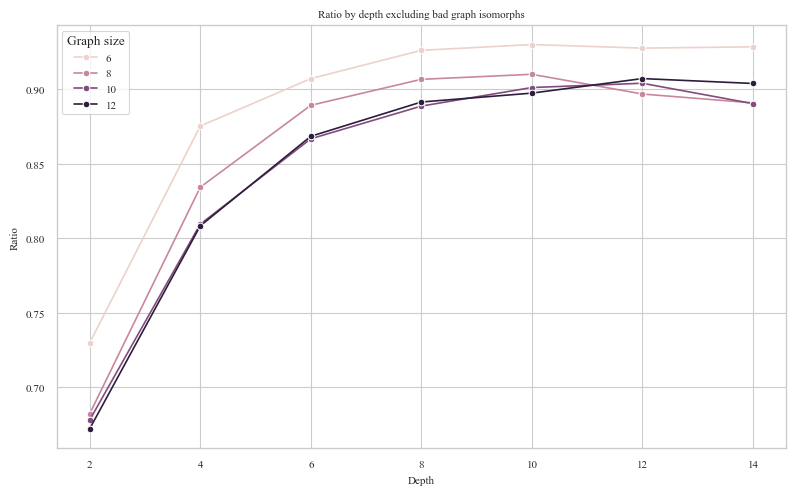

In [35]:
from networkx.algorithms import isomorphism

bad_group = groups_by_size[8][0]
bad_graph_obj = bad_group["repr"] if isinstance(bad_group, dict) and "repr" in bad_group else bad_group
bad_graph_unweighted = nx.Graph()
bad_graph_unweighted.add_nodes_from(bad_graph_obj.nodes())
bad_graph_unweighted.add_edges_from(bad_graph_obj.edges())

def to_unweighted_nx(graph_dict):
    if not isinstance(graph_dict, dict):
        return None
    b64 = graph_dict.get("__bytes_b64__")
    if not isinstance(b64, str):
        return None
    obj = pickle.loads(base64.b64decode(b64))

    if isinstance(obj, nx.Graph):
        G = obj
    elif hasattr(obj, "to_networkx"):
        G = obj.to_networkx()
    elif hasattr(obj, "edges") and hasattr(obj, "nodes"):
        G = nx.Graph()
        G.add_nodes_from(obj.nodes())
        # Filter out invalid edges
        valid_edges = [e for e in obj.edges() if isinstance(e, (tuple, list)) and len(e) >= 2]
        G.add_edges_from(valid_edges)
    else:
        raise ValueError("Cannot convert graph object to networkx Graph")

    Gu = nx.Graph()
    Gu.add_nodes_from(G.nodes())
    # Filter out invalid edges before adding
    valid_edges = [e for e in G.edges() if isinstance(e, (tuple, list)) and len(e) >= 2]
    Gu.add_edges_from(valid_edges)
    return Gu

def is_isomorphic_to_bad(graph_dict):
    G = to_unweighted_nx(graph_dict)
    return nx.is_isomorphic(G, bad_graph_unweighted)

df_excluding_bad = df.copy()
df_excluding_bad = df_excluding_bad[df_excluding_bad['qaoa_variant']=='vanilla']
df_excluding_bad["graph_b64"] = df_excluding_bad["graph"].apply(
    lambda g: g.get("__bytes_b64__") if isinstance(g, dict) else None
)

iso_cache = {}
for b64 in df_excluding_bad["graph_b64"].dropna().unique():
    iso_cache[b64] = is_isomorphic_to_bad({"__bytes_b64__": b64})

df_excluding_bad = df_excluding_bad[
    ~df_excluding_bad["graph_b64"].map(iso_cache).fillna(False)
].copy()

fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(
    data=df_excluding_bad,
    x="depth",
    y="ratio",
    hue="graph_size",
    estimator="mean",
    ci=None,
    marker="o",
    ax=ax
)

ax.set_title("Ratio by depth excluding bad graph isomorphs")
ax.set_xlabel("Depth")
ax.set_ylabel("Ratio")
ax.legend(title="Graph size")
plt.tight_layout()
plt.show()

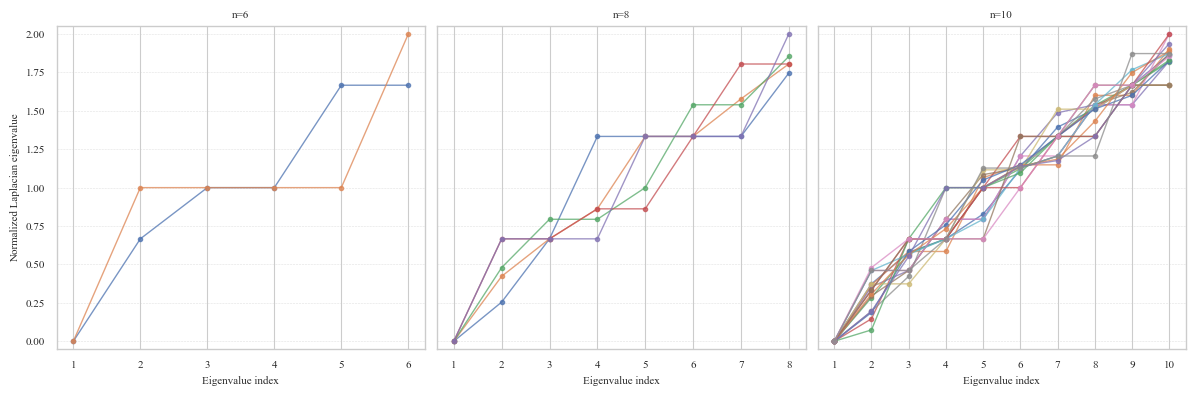

In [14]:
# Plot normalized Laplacian eigenvalues for each generated graph
graph_eigvals = []
for idx, G in enumerate(unique_graphs):
    L_norm = nx.normalized_laplacian_matrix(G).toarray()
    eigs = np.linalg.eigvalsh(L_norm)
    graph_eigvals.append({
        "graph_index": idx + 1,
        "graph_size": G.number_of_nodes(),
        "eigenvalues": np.sort(eigs),
    })

sizes = sorted({item["graph_size"] for item in graph_eigvals})
fig, axes = plt.subplots(1, len(sizes), figsize=(12, 4), sharey=True)

for ax, size in zip(axes, sizes):
    for item in [g for g in graph_eigvals if g["graph_size"] == size]:
        ax.plot(
            np.arange(1, len(item["eigenvalues"]) + 1),
            item["eigenvalues"],
            marker="o",
            markersize=3,
            linewidth=1,
            alpha=0.75,
            label=f"G{item['graph_index']}"
        )
    ax.set_title(f"n={size}")
    ax.set_xlabel("Eigenvalue index")
    ax.set_xticks(np.arange(1, size + 1))
    ax.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.6)
    ax.set_ylim(-0.05, 2.05)
    if size == sizes[0]:
        ax.set_ylabel("Normalized Laplacian eigenvalue")

# Optionally hide legend for crowded plots
if len(graph_eigvals) <= 15:
    axes[-1].legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()


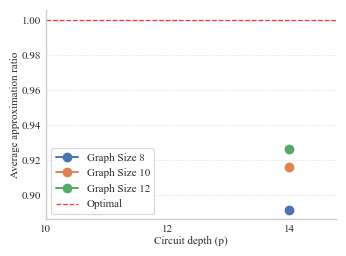

graph_size        8         10        12
depth                                   
14          0.891274  0.915557  0.926215


In [27]:
# Filter data for vanilla QAOA with depth in [10, 12, 14], no warm start, lagrangian multiplier = 2
vanilla_filtered = results[
    (results['qaoa_variant'] == 'vanilla') &
    (results['depth'].isin([10, 12, 14])) &
    (results['warm_start'] == False) &
    (results['lagrangian_multiplier'] == 2)
].copy()
vanilla_filtered = rerun_df
# Calculate average ratio for each depth and graph_size
avg_ratio_by_depth_size = vanilla_filtered.groupby(['depth', 'graph_size'])['ratio'].mean().unstack()

# Plot
fig, ax = plt.subplots(figsize=DEFUALT_COLUMN_FIGSIZE)

for graph_size in avg_ratio_by_depth_size.columns:
    ax.plot(
        avg_ratio_by_depth_size.index,
        avg_ratio_by_depth_size[graph_size],
        marker='o',
        linewidth=1.4,
        markersize=6,
        label=f'Graph Size {graph_size}'
    )

ax.axhline(y=1.0, color=OPTIMAL_LINE_COLOR, linestyle='--', linewidth=0.9, alpha=0.8, label='Optimal')

ax.set_xlabel('Circuit depth (p)', labelpad=1)
ax.set_ylabel('Average approximation ratio', labelpad=1)
ax.set_xticks([10, 12, 14])
ax.tick_params(axis='both', pad=1, length=2.5)
ax.grid(axis='y', linestyle='--', linewidth=0.45, alpha=0.55)
ax.grid(axis='x', visible=False)
ax.legend(frameon=True)

sns.despine()
fig.subplots_adjust(left=0.17, right=0.98, bottom=0.16, top=0.98)

plt.tight_layout()
plt.show()

print(avg_ratio_by_depth_size)

In [28]:
counts = (
    results.groupby(
        ['qaoa_variant', 'depth', 'graph_size', 'warm_start', 'hamming_dist', 'lagrangian_multiplier']
    )
    .size()
    .to_frame('count')
    .sort_index()
)

counts

count
qaoa_variant depth graph_size warm_start hamming_dist lagrangian_multiplier       
multiangle   1     6          False      0            2                       1000
                   8          False      0            2                       1000
                   10         False      0            2                       1000
                   12         False      0            2                       1000
             2     6          False      0            2                       1000
...                                                                            ...
vanilla      12    12         False      0            2                       1000
             14    6          False      0            2                       1000
                   8          False      0            2                       1000
                   10         False      0            2                       1000
                   12         False      0            2                       1000

[94 rows x 1 columns]

In [29]:
print(counts.to_string())

                                                                             count
qaoa_variant depth graph_size warm_start hamming_dist lagrangian_multiplier       
multiangle   1     6          False      0            2                       1000
                   8          False      0            2                       1000
                   10         False      0            2                       1000
                   12         False      0            2                       1000
             2     6          False      0            2                       1000
                   8          False      0            2                       1000
                   10         False      0            2                       1000
                   12         False      0            2                       1000
             3     6          False      0            2                       1000
                   8          False      0            2                       1000
    

In [30]:
import networkx as nx
from functools import lru_cache
from networkx.algorithms import isomorphism

@lru_cache(maxsize=None)
def load_nx_graph_from_b64(graph_b64: str):
    obj = pickle.loads(base64.b64decode(graph_b64))

    if isinstance(obj, nx.Graph):
        return obj

    if hasattr(obj, "to_networkx"):
        return obj.to_networkx()

    if hasattr(obj, "edge_list"):
        edges = []
        for edge in obj.edge_list():
            edges.append(tuple(edge))
        G = nx.Graph()
        if hasattr(obj, "node_list"):
            G.add_nodes_from(obj.node_list())
        elif hasattr(obj, "num_nodes"):
            G.add_nodes_from(range(obj.num_nodes()))
        G.add_edges_from(edges)
        return G

    if hasattr(obj, "edges") and hasattr(obj, "nodes"):
        edges = [tuple(edge) for edge in obj.edges()]
        G = nx.Graph()
        G.add_nodes_from(obj.nodes())
        G.add_edges_from(edges)
        return G

    raise RuntimeError("Cannot convert graph object to networkx Graph")

graph_representatives = []

def graph_iso_group_from_b64(graph_b64: str):
    G = load_nx_graph_from_b64(graph_b64)
    for group_id, H in graph_representatives:
        if isomorphism.GraphMatcher(G, H).is_isomorphic():
            return group_id
    group_id = len(graph_representatives)
    graph_representatives.append((group_id, G))
    return group_id

subset_v = results[results["qaoa_variant"] == "vanilla"].copy()

subset_v["graph_b64"] = subset_v["graph"].apply(
    lambda g: g.get("__bytes_b64__") if isinstance(g, dict) else None
)

subset_v["graph_iso_group"] = subset_v["graph_b64"].apply(
    lambda g: graph_iso_group_from_b64(g) if g is not None else None
)

iso_groups = (
    subset_v
    .groupby(["graph_iso_group", "graph_size"])
    .agg(run_count=("ratio", "size"), unique_graphs=("graph_b64", "nunique"))
    .sort_values(["run_count", "unique_graphs"], ascending=False)
)

print("Isomorphic graph groups (structure only, ignoring weights):")
print(iso_groups.head(20))

graph_size_8 = subset_v[subset_v["graph_size"] == 8].copy()
print("Graph size 8 isomorphism groups:")
print(graph_size_8.groupby("graph_iso_group").size().sort_values(ascending=False).head(20))

KeyboardInterrupt: 

In [ ]:
# Group by graph_size and graph_iso_group, compute mean ratio, sort by graph_size ascending
ratios_per_iso_group = subset_v.groupby(['graph_size', 'graph_iso_group'])['ratio'].mean().reset_index().sort_values(['graph_size', 'graph_iso_group'])

ratios_per_iso_group

,graph_size,graph_iso_group,ratio
0,6,16,0.892207
1,6,17,0.873949
2,8,18,0.849531
3,8,19,0.842322
4,8,20,0.874673
...,...,...,...
80,12,80,0.812913
81,12,81,0.936011
82,12,82,0.956424
83,12,83,0.905646


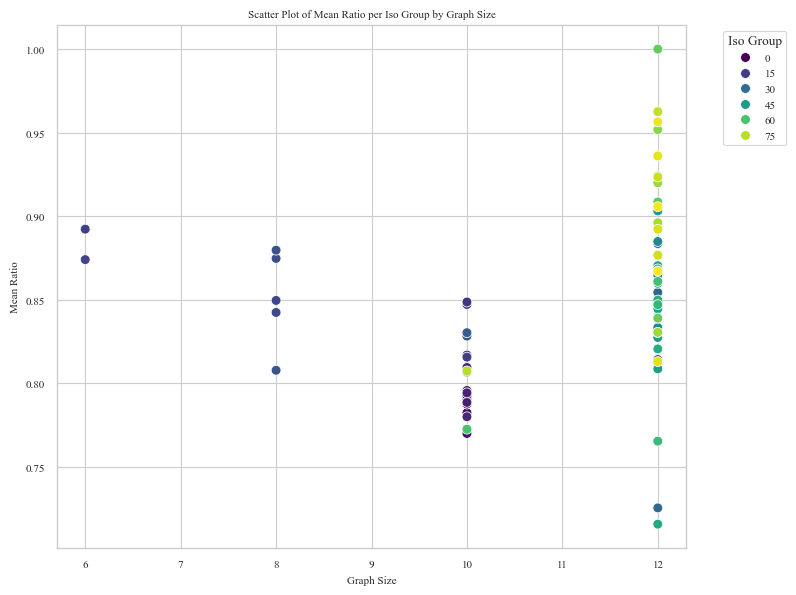

In [ ]:
import seaborn as sns

import matplotlib.pyplot as plt

# Assuming ratios_per_iso_group is available from previous cells
plt.figure(figsize=(8, 6))
sns.scatterplot(data=ratios_per_iso_group, x='graph_size', y='ratio', hue='graph_iso_group', palette='viridis', s=50)
plt.xlabel('Graph Size')
plt.ylabel('Mean Ratio')
plt.title('Scatter Plot of Mean Ratio per Iso Group by Graph Size')
plt.legend(title='Iso Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
for c in ['qaoa_variant','depth','warm_start','hamming_dist','lagrangian_multiplier']:
    if results[c].apply(lambda x: isinstance(x, list)).any():
        print(c, "contains lists")

In [ ]:

df = results.copy()

def graph_id_from_graphcol(g):
    # g is expected to be a dict like {"__bytes_b64__": "..."}
    if not isinstance(g, dict):
        return None
    b64 = g.get("__bytes_b64__")
    if not b64:
        return None
    return hashlib.sha1(b64.encode("ascii")).hexdigest()[:12]

df["graph_id"] = df["graph"].apply(graph_id_from_graphcol)

print("rows:", len(df))
print("unique graphs:", df["graph_id"].nunique())

print("\nunique graphs by (size, degree, weighted):")
print(df.groupby(["graph_size", "graph_degree", "graph_weighted"])["graph_id"].nunique())

print("\nunique graphs by depth:")
print(df.groupby(["depth"])["graph_id"].nunique())

print("\nunique graphs by qaoa_variant:")
print(df.groupby(["qaoa_variant"])["graph_id"].nunique())

print("\nreuse stats (how many runs share the same graph):")
print(df.groupby("graph_id").size().describe())


rows: 93943
unique graphs: 900

unique graphs by (size, degree, weighted):
graph_size  graph_degree  graph_weighted
6           3             True              100
8           3             True              200
10          3             True              400
12          3             True              200
Name: graph_id, dtype: int64

unique graphs by depth:
depth
1     200
2     400
3     300
4     400
5     200
6     400
7     200
8     200
10    300
12    200
14    200
Name: graph_id, dtype: int64

unique graphs by qaoa_variant:
qaoa_variant
multiangle    300
vanilla       600
Name: graph_id, dtype: int64

reuse stats (how many runs share the same graph):
count    900.000000
mean     104.381111
std       87.731834
min       20.000000
25%       40.000000
50%       80.000000
75%      140.000000
max      320.000000
dtype: float64


In [ ]:
# Count data points for each unique combination of the requested columns
cols = ['qaoa_variant', 'warm_start', 'depth', 'lagrangian_multiplier', 'hamming_dist', 'graph_size','graph_degree']
grouped = results.groupby(cols).size().reset_index(name='count')

# Summary
print(f"Total unique combinations: {len(grouped)}\n")

# Print each unique combination with its count (sorted by count descending)
pd.set_option('display.max_rows', None)
print(grouped.sort_values(['count','qaoa_variant', 'warm_start', 'depth'], ascending=False).to_string(index=False))
pd.reset_option('display.max_rows')

# Basic statistics about the counts
print("\nCount statistics:")
print(grouped['count'].describe())
print(len(results))

Total unique combinations: 94

qaoa_variant  warm_start  depth  lagrangian_multiplier  hamming_dist  graph_size  graph_degree  count
     vanilla        True     10                      1             0          10             3   1000
     vanilla        True     10                      1             2          10             3   1000
     vanilla        True     10                      1             4          10             3   1000
     vanilla        True     10                      1             6          10             3   1000
     vanilla        True     10                      2             0          10             3   1000
     vanilla        True     10                      2             2          10             3   1000
     vanilla        True     10                      2             4          10             3   1000
     vanilla        True     10                      2             6          10             3   1000
     vanilla        True     10                    

### Results for comparisons between m- and v-qaoa

In [22]:
# Create a copy of results to work with
df = results[(results['warm_start']==False) &( results['lagrangian_multiplier'] ==2)].copy()

In [23]:

df['ratio'] = df['classic_value']/df['final_expectation_value']

In [24]:
print(len(df))

56000


In [ ]:
save_images = True

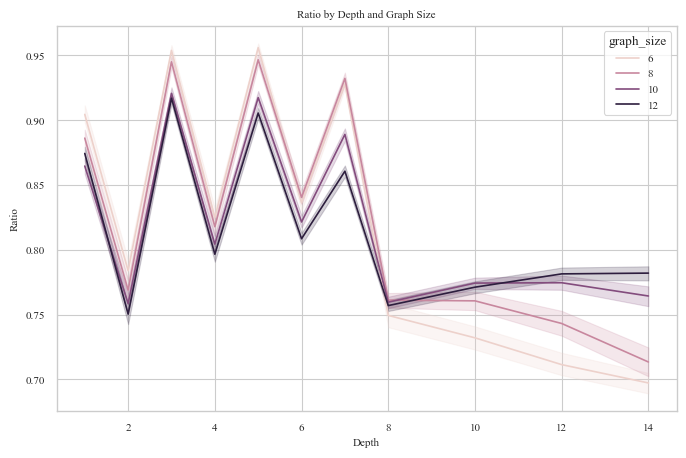

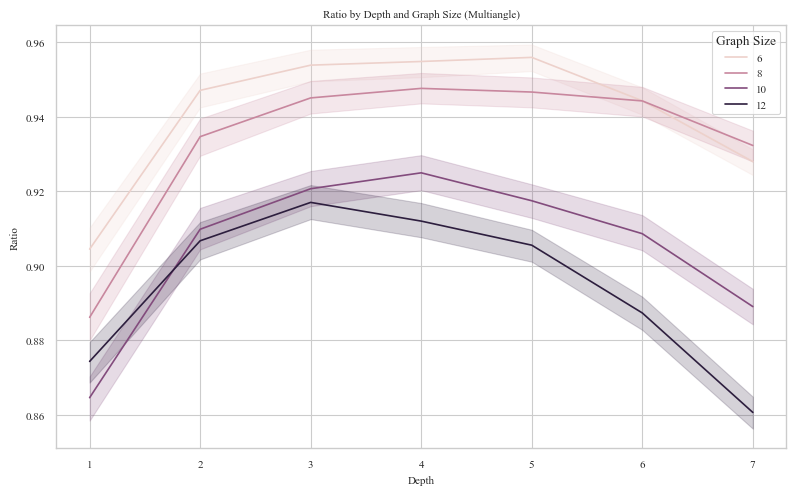

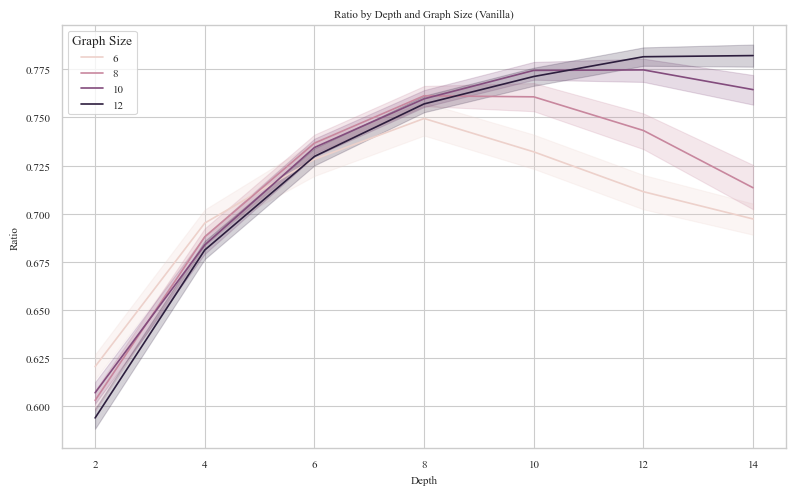

<Figure size 640x480 with 0 Axes>

In [30]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.lineplot(
    data=df,
    x="depth",
    y="ratio",
    hue="graph_size",
    ax=ax
)

ax.set_xlabel("Depth")
ax.set_ylabel("Ratio")
ax.set_title("Ratio by Depth and Graph Size")
subset_ma = df[df["qaoa_variant"] == "multiangle"]
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(
    data=subset_ma,
    x="depth",
    y="ratio",
    hue="graph_size",
    ax=ax
)
ax.set_xlabel("Depth")
ax.set_ylabel("Ratio")
ax.set_title("Ratio by Depth and Graph Size (Multiangle)")
ax.legend(title="Graph Size")
plt.tight_layout()
plt.show()

subset_v = df[df["qaoa_variant"] == "vanilla"]
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(
    data=subset_v,
    x="depth",
    y="ratio",
    hue="graph_size",
    ax=ax
)
ax.set_xlabel("Depth")
ax.set_ylabel("Ratio")
ax.set_title("Ratio by Depth and Graph Size (Vanilla)")
ax.legend(title="Graph Size")
plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

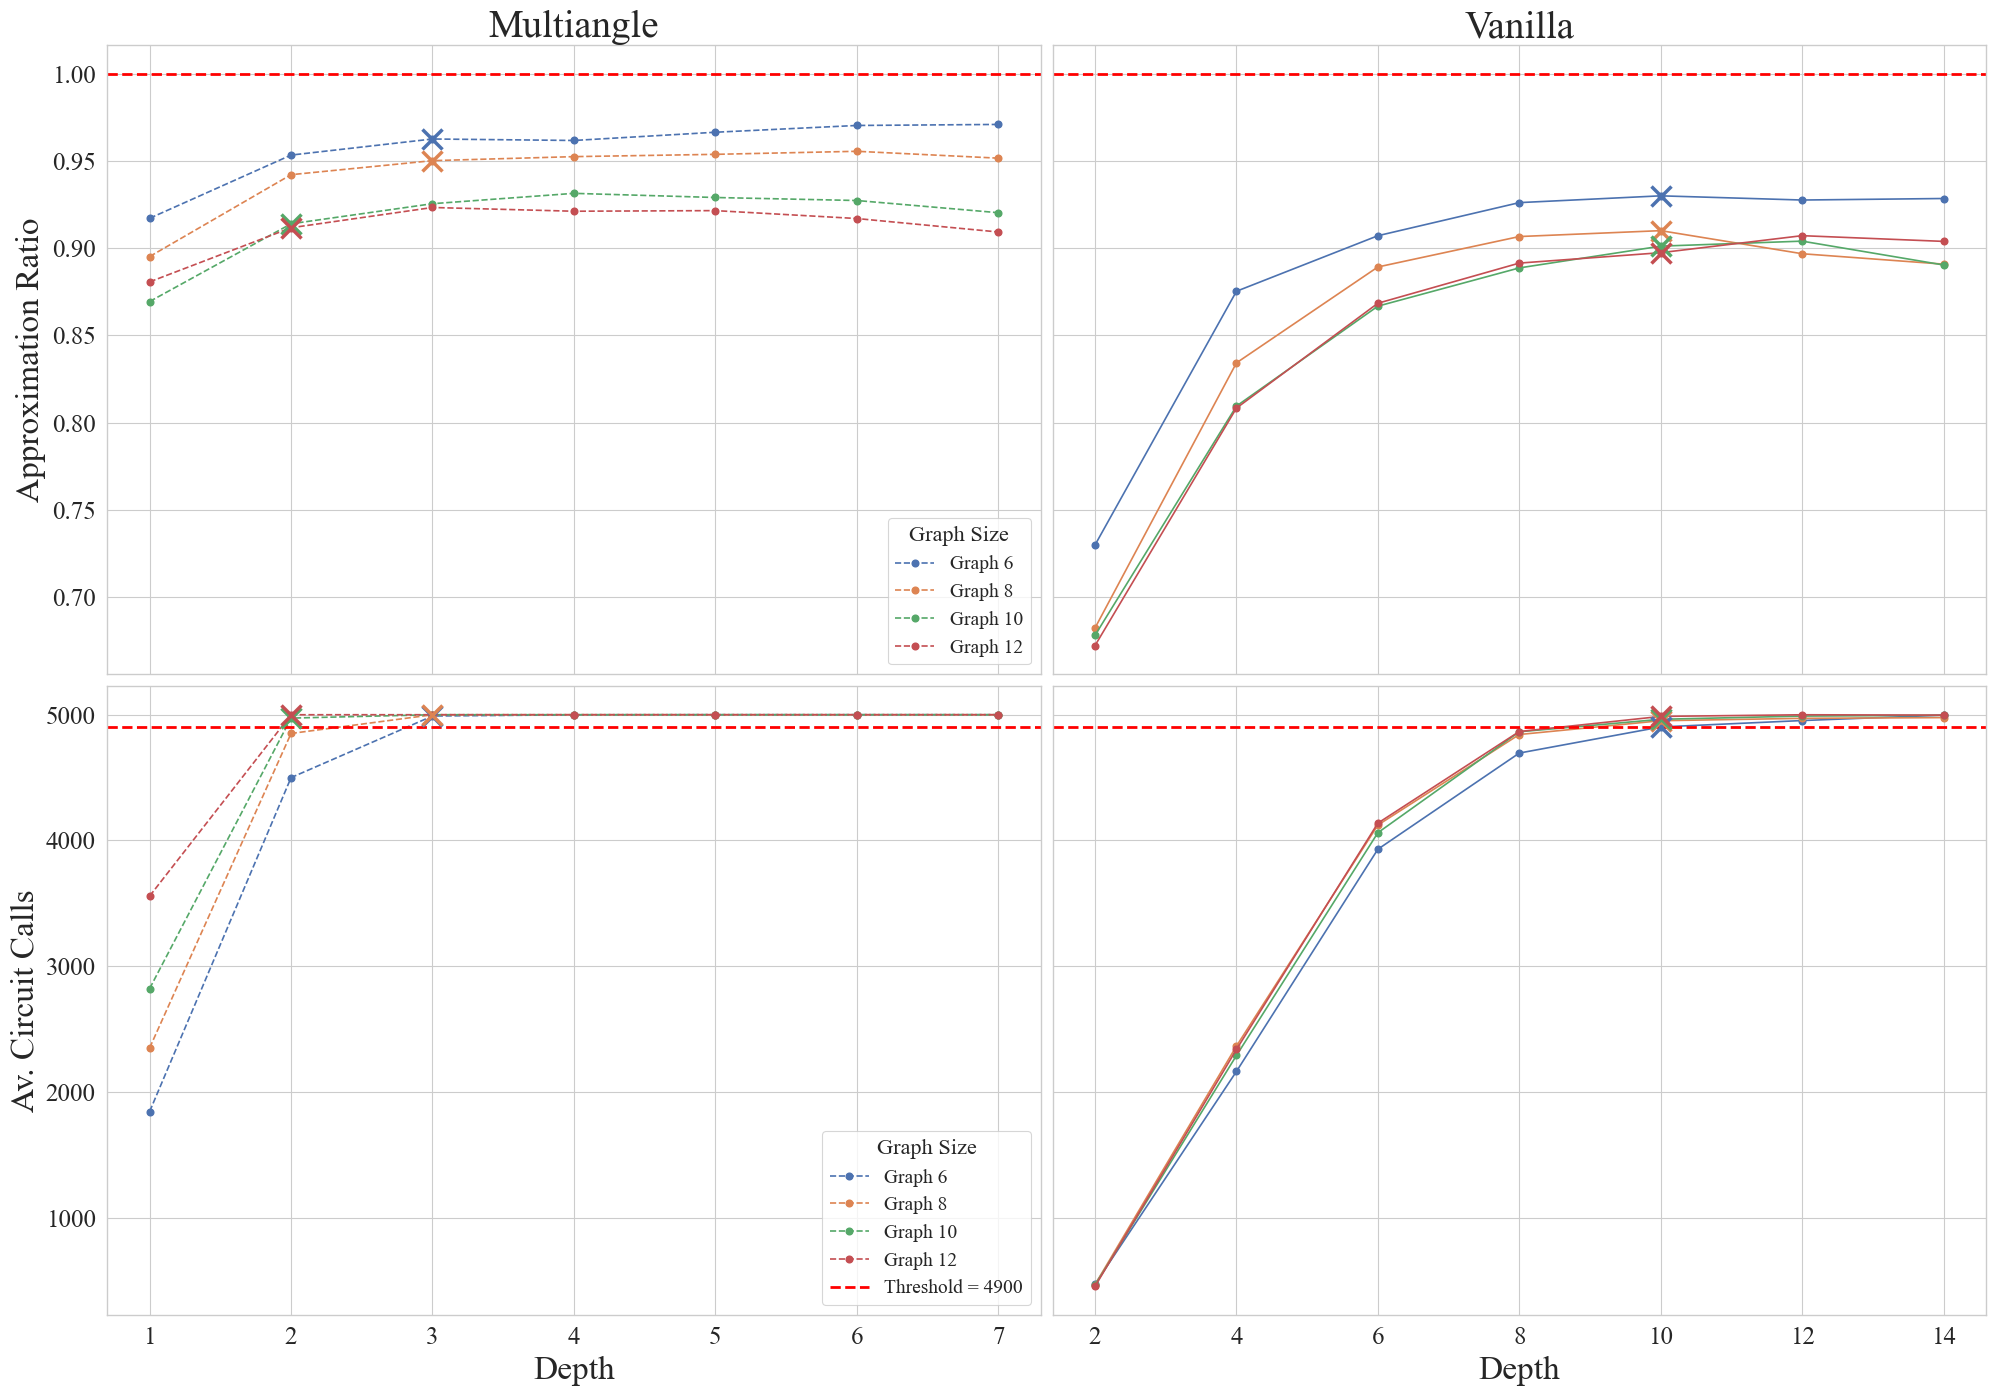

In [36]:
df['graph_name'] = df['graph identifier']



variants = QAOA_VARIANTS
limit = 4900

# 2 rows x 2 cols: row0=ratio, row1=evals | col0=multiangle, col1=vanilla
fig, axes = plt.subplots(2, 2, figsize=(20, 14), sharex='col', sharey='row')

legend_handles = {}  # keyed by graph_size, shared across variants

for col, variant in enumerate(variants):
    variant_df = df[df['qaoa_variant'] == variant]
    variant_linestyle = QAOA_VARIANT_LINESTYLES.get(variant, "-")

    for graph_size, size_df in variant_df.groupby("graph_size"):
        depth_ratio = size_df.groupby("depth")["ratio"].mean()
        depth_evals = size_df.groupby("depth")["quantum_func_evals"].mean()

        # --- Row 0: Ratio ---
        line = axes[0, col].plot(
            depth_ratio.index,
            depth_ratio.values,
            marker='o',
            linestyle=variant_linestyle,
            label=f"Graph {graph_size}"
        )
        color = line[0].get_color()

        # Store handle once (same color used in both columns)
        if graph_size not in legend_handles:
            legend_handles[graph_size] = line[0]

        # --- Row 1: Evals ---
        axes[1, col].plot(
            depth_evals.index,
            depth_evals.values,
            marker='o',
            color=color,
            linestyle=variant_linestyle,
            label=f"Graph {graph_size}"
        )

        # --- Threshold markers ---
        exceeds = depth_evals[depth_evals > limit]
        if not exceeds.empty:
            threshold_depth = exceeds.index.min()

            avg_ratio = size_df[size_df["depth"] == threshold_depth]["ratio"].mean()
            axes[0, col].plot(threshold_depth, avg_ratio, marker='x', markersize=14,
                              markeredgewidth=2.5, color=color, zorder=5)

            avg_eval = size_df[size_df["depth"] == threshold_depth]["quantum_func_evals"].mean()
            axes[1, col].plot(threshold_depth, avg_eval, marker='x', markersize=14,
                              markeredgewidth=2.5, color=color, zorder=5)

# --- Formatting ---
col_titles = [QAOA_VARIANT_LABELS[v] for v in QAOA_VARIANTS]

for col in range(2):
    # Row 0: ratio
    axes[0, col].axhline(y=1, color=OPTIMAL_LINE_COLOR, linestyle='--', linewidth=2)
    axes[0, col].set_title(col_titles[col], fontsize=28)
    axes[0, col].tick_params(axis='both', labelsize=18)
    axes[0, col].set_ylabel("Approximation Ratio" if col == 0 else "", fontsize=24)
    axes[0, col].tick_params(axis='x', labelbottom=False)  # hide x labels on row 0

    # Row 1: evals
    axes[1, col].axhline(y=limit, color=OPTIMAL_LINE_COLOR, linestyle='--', linewidth=2, label=f'Threshold = {limit}')
    axes[1, col].set_xlabel("Depth", fontsize=24)
    axes[1, col].tick_params(axis='both', labelsize=18)
    axes[1, col].set_ylabel("Av. Circuit Calls" if col == 0 else "", fontsize=24)

# --- Legends only on left column ---
axes[0, 0].legend(
    handles=list(legend_handles.values()),
    labels=[f"Graph {k}" for k in legend_handles.keys()],
    title="Graph Size", title_fontsize=16, fontsize=14, loc="lower right"
)
axes[1, 0].legend(title="Graph Size", title_fontsize=16, fontsize=14, loc="lower right")
plt.tight_layout()

if save_images:
    pass #plt.savefig('pdf_images/CS_allgraphs_comparison.pdf', bbox_inches='tight')

plt.show()

56000
0.0
0.0
0.0
0.0
0.0
0.0
0.0
10.100000000000001
3.15
1.4500000000000002
1.125
1.125
2.0500000000000003
3.1


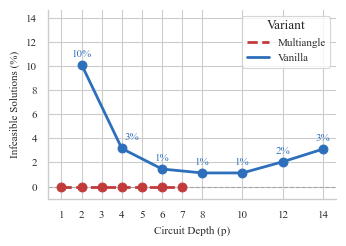

In [ ]:
df_analysis = df.copy()
print(len(df_analysis))
grouped = (
    df_analysis
    .groupby(['qaoa_variant', 'depth', 'feasible'])
    .size()
    .reset_index(name='count')
)

pivot_df = grouped.pivot_table(
    index=['qaoa_variant', 'depth'],
    columns='feasible',
    values='count',
    fill_value=0
).reset_index()

pivot_df.rename(columns={True: 'feasible', False: 'infeasible'}, inplace=True)

for col in ['feasible', 'infeasible']:
    if col not in pivot_df.columns:
        pivot_df[col] = 0

pivot_df['total'] = pivot_df['feasible'] + pivot_df['infeasible']
pivot_df['feasible_pct'] = pivot_df['feasible'] / pivot_df['total'] * 100
pivot_df['infeasible_pct'] = pivot_df['infeasible'] / pivot_df['total'] * 100

# Sort so multiangle comes first, then vanilla
pivot_df['qaoa_variant'] = pd.Categorical(pivot_df['qaoa_variant'], categories=QAOA_VARIANTS, ordered=True)
pivot_df = pivot_df.sort_values(['qaoa_variant', 'depth']).reset_index(drop=True)

pivot_df['label'] = pivot_df['depth'].apply(lambda d: f"P = {d}")




colors = QAOA_VARIANT_COLORS
labels = QAOA_VARIANT_LABELS

fig, ax = plt.subplots(figsize=(3.5, 2.5))


for variant in QAOA_VARIANTS:
    df_var = pivot_df[pivot_df['qaoa_variant'] == variant].copy()
    x = df_var['depth'].values
    y = df_var['infeasible_pct'].values
    is_almost_perfect = (df_var['feasible_pct'].values >= 99.5) & (df_var['feasible_pct'].values < 100)

    color = colors[variant]
    linestyle = QAOA_VARIANT_LINESTYLES.get(variant, "-")

    # Main line
    ax.plot(x, y, color=color, linestyle=linestyle, linewidth=2, label=labels[variant], zorder=3)

    # Regular dots
    ax.scatter(x, y,
               color=color, s=40, zorder=5)



    for xi, yi in zip(x, y):
        print(yi)

        if yi > 0 :

            txt = f"*" if (yi < 0.5) else f"{yi:.0f}%"
            if xi == 4 and variant =='vanilla':
                ax.text(
                    xi  + 0.5 , yi + 0.5, txt,
                    ha='center',
                    va='bottom',
                    color=color
                )
            else:
                ax.text(
                    xi , yi + 0.5, txt,
                    ha='center',
                    va='bottom',
                    color=color
                )

# Reference line at 0
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)

ax.set_xlabel("Circuit Depth (p)")
ax.set_ylabel("Infeasible Solutions (%)")
ax.set_ylim(-1, max(pivot_df['infeasible_pct']) * 1.25 + 2)

# Make sure all depth values appear on x-axis
all_depths = sorted(pivot_df['depth'].unique())
ax.set_xticks(all_depths)
ax.set_xticklabels(all_depths)

# Legend — deduplicate entries
handles, labs = ax.get_legend_handles_labels()
# Keep one "perfect" label, drop duplicates
seen = {}
for h, l in zip(handles, labs):
    if l not in seen:
        seen[l] = h
ax.legend(seen.values(), seen.keys(),  title="Variant", frameon=True)

sns.despine()
plt.tight_layout()
if True:
    plt.savefig('pdf_images/CS_feasible_percent.pdf', bbox_inches='tight')
plt.show()

In [ ]:
def final_params_length(fp):
    if isinstance(fp, dict) and "__ndarray__" in fp:
        return len(fp["__ndarray__"])
    if hasattr(fp, "__len__"):
        return len(fp)
    return None

results["final_params_len"] = results["final_params"].apply(final_params_length)

summary = (
    results
    .groupby(["graph_size", "depth", "qaoa_variant"])["final_params_len"]
    .agg(["count", "min", "max", "nunique"])
    .reset_index()
)

print(summary.to_string(index=False))

 graph_size  depth qaoa_variant  count  min  max  nunique
          6      1   multiangle   1000   21   21        1
          6      2   multiangle   1000   42   42        1
          6      2      vanilla   1000    4    4        1
          6      3   multiangle   1000   63   63        1
          6      4   multiangle   1000   84   84        1
          6      4      vanilla   1000    8    8        1
          6      5   multiangle   1000  105  105        1
          6      6   multiangle   1000  126  126        1
          6      6      vanilla   1000   12   12        1
          6      7   multiangle   1000  147  147        1
          6      8      vanilla   1000   16   16        1
          6     10      vanilla   1000   20   20        1
          6     12      vanilla   1000   24   24        1
          6     14      vanilla   1000   28   28        1
          8      1   multiangle   1000   28   28        1
          8      2   multiangle   1000   56   56        1
          8   

In [ ]:
subset = results[(results["depth"] == 3) & (results["graph_size"] == 10)]

if len(subset):
    print(subset["final_params"].sample(n=1, random_state=42).iloc[0])
else:
    print("No rows found for depth=3 and graph_size=10")

{'__ndarray__': [1.600132596858805, 0.4037591966721932, 2.1697954330739857, 0.5241771698137018, 1.1813221934000293, 6.29944767575818, 4.99262267126936, 1.5607192676143886, 1.0331184017006358, -0.5158743899847792, 2.0394002658544266, 7.571814160497311, 6.201870947506379, 3.58160133588999, 3.1048558511539905, 3.194011222058627, 3.4533286218632426, 4.44680230250331, 3.14448208179602, 5.921652502692853, 1.981042757537847, 0.1946071131706064, 6.250675944707891, 3.8894073354110965, 1.0317339129781593, 0.9427782939886791, 2.027577663932532, 2.095061699961456, 1.2545281617230868, 0.9707482051277776, 2.1654716318672405, 0.8845913143662565, -0.037759730458721566, 0.5682569059630828, 2.0847470912103114, 4.15922824626992, 6.267600411863196, 6.316094811292549, 1.5316628438034021, 0.7521912762443927, 4.734127229359493, 1.0994634672739652, 5.567741243895479, 3.4972997610571834, 1.588549161654996, 0.637603081250116, 1.7578578927258506, 3.028332586071227, 2.240913466324459, 2.846113905541808, 1.2903028

In [ ]:
filtered_results =df.copy()
# Group by qaoa_variant and depth, then calculate percentage of infeasible solutions
grouped = filtered_results.groupby(['qaoa_variant', 'depth'])
for (variant, depth), group in grouped:
    total_runs = len(group)
    infeasible_runs = len(group[group['feasible'] == False])
    percentage_infeasible = (infeasible_runs / total_runs) * 100 if total_runs > 0 else 0
    print(f"Variant: {variant}, Depth: {depth}, Percentage of infeasible solutions: {percentage_infeasible:.2f}%")

Variant: multiangle, Depth: 1, Percentage of infeasible solutions: 0.00%
Variant: multiangle, Depth: 2, Percentage of infeasible solutions: 0.00%
Variant: multiangle, Depth: 3, Percentage of infeasible solutions: 0.00%
Variant: multiangle, Depth: 4, Percentage of infeasible solutions: 0.00%
Variant: multiangle, Depth: 5, Percentage of infeasible solutions: 0.00%
Variant: multiangle, Depth: 6, Percentage of infeasible solutions: 0.00%
Variant: multiangle, Depth: 7, Percentage of infeasible solutions: 0.00%
Variant: vanilla, Depth: 2, Percentage of infeasible solutions: 10.10%
Variant: vanilla, Depth: 4, Percentage of infeasible solutions: 3.15%
Variant: vanilla, Depth: 6, Percentage of infeasible solutions: 1.45%
Variant: vanilla, Depth: 8, Percentage of infeasible solutions: 1.12%
Variant: vanilla, Depth: 10, Percentage of infeasible solutions: 1.12%
Variant: vanilla, Depth: 12, Percentage of infeasible solutions: 2.05%
Variant: vanilla, Depth: 14, Percentage of infeasible solutions: 3

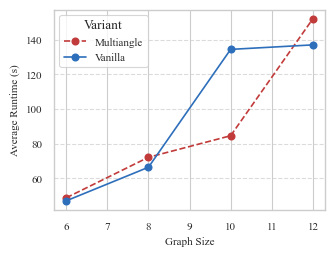

In [ ]:
# Plot average runtime per graph size for each QAOA variant
grouped = results.groupby(['qaoa_variant', 'graph_size'])['time_elapsed'].mean().reset_index()

fig, ax = plt.subplots(figsize=DEFUALT_COLUMN_FIGSIZE)

for variant in QAOA_VARIANTS:
    sub = grouped[grouped['qaoa_variant'] == variant]
    ax.plot(
        sub['graph_size'], 
        sub['time_elapsed'], 
        label=QAOA_VARIANT_LABELS[variant], 
        marker='o',
        linestyle=QAOA_VARIANT_LINESTYLES[variant],
        color=QAOA_VARIANT_COLORS[variant]
    )

ax.set_xlabel('Graph Size')
ax.set_ylabel('Average Runtime (s)')
ax.legend(title='Variant')
ax.grid(axis='y', linestyle='--', alpha=0.7)

if save_images:
    plt.savefig('pdf_images/runtime_per_graph_size.pdf', bbox_inches='tight')

plt.show()

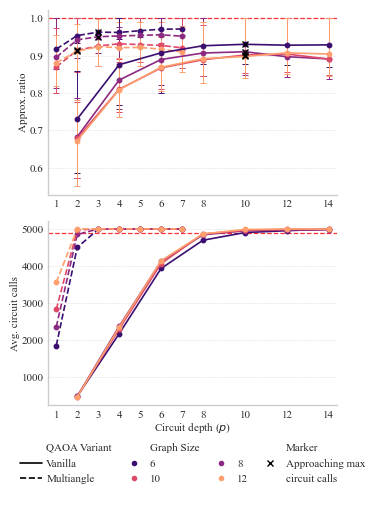

In [37]:
from matplotlib.lines import Line2D

def plot_qaoa_ratio_and_calls_combined_with_legend(df, save_images=False):
    sns.set_theme(**PLOT_THEME)
    plt.rcParams.update(PLOT_RCPARAMS)

    df_plot = df.copy()
    df_plot["depth"] = pd.to_numeric(df_plot["depth"], errors="coerce")
    df_plot["ratio"] = pd.to_numeric(df_plot["ratio"], errors="coerce")
    df_plot["quantum_func_evals"] = pd.to_numeric(df_plot["quantum_func_evals"], errors="coerce")
    df_plot["graph_size"] = pd.to_numeric(df_plot["graph_size"], errors="coerce")

    df_plot = df_plot.dropna(
        subset=["qaoa_variant", "graph_size", "depth", "ratio", "quantum_func_evals"]
    )

    limit = 4900

    summary = (
        df_plot
        .groupby(["qaoa_variant", "graph_size", "depth"], as_index=False)
        .agg(
            mean_ratio=("ratio", "mean"),
            q25_ratio=("ratio", lambda x: np.percentile(x, 25)),
            q75_ratio=("ratio", lambda x: np.percentile(x, 75)),
            mean_calls=("quantum_func_evals", "mean"),
        )
        .sort_values(["qaoa_variant", "graph_size", "depth"])
    )

    graph_sizes = sorted(summary["graph_size"].unique())

    graph_size_colors = {
        gs: sns.color_palette("magma", n_colors=len(graph_sizes))[i]
        for i, gs in enumerate(graph_sizes)
    }

    variant_styles = {
        v: {
            "linestyle": QAOA_VARIANT_LINESTYLES[v],
            "marker": "o",
        }
        for v in QAOA_VARIANTS
    }

    all_depths = sorted(summary["depth"].unique())

    fig = plt.figure(figsize=(DEFUALT_COLUMN_FIGSIZE[0], 5.2))
    gs = fig.add_gridspec(3, 1, height_ratios=[1, 1, 0.35])

    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax_leg = fig.add_subplot(gs[2])

    def style_axis(ax, ylabel, xlabel=None):
        ax.set_ylabel(ylabel, labelpad=1)
        if xlabel:
            ax.set_xlabel(xlabel, labelpad=1)

        ax.tick_params(axis="both", pad=0.8, length=2.5)
        ax.grid(axis="y", linestyle="--", linewidth=0.45, alpha=0.55)
        ax.grid(axis="x", visible=False)
        ax.margins(x=0.03, y=0.05)
        sns.despine(ax=ax)

    # ---------- ratio with 25--75 percentile error bars ----------
    for variant in QAOA_VARIANTS:
        variant_df = summary[summary["qaoa_variant"] == variant]
        style = variant_styles[variant]

        for graph_size in sorted(variant_df["graph_size"].unique()):
            cur = variant_df[variant_df["graph_size"] == graph_size].sort_values("depth")
            color = graph_size_colors[graph_size]

            y = cur["mean_ratio"].values
            yerr_lower = y - cur["q25_ratio"].values
            yerr_upper = cur["q75_ratio"].values - y

            ax1.errorbar(
                cur["depth"],
                y,
                yerr=[yerr_lower, yerr_upper],
                linestyle=style["linestyle"],
                marker=style["marker"],
                markersize=3.2,
                linewidth=1.2,
                elinewidth=0.7,
                capsize=2,
                capthick=0.7,
                color=color,
                zorder=3,
            )

            exceeds = cur[cur["mean_calls"] > limit]
            if not exceeds.empty:
                threshold_depth = exceeds["depth"].iloc[0]
                ratio_y = cur.loc[cur["depth"] == threshold_depth, "mean_ratio"].iloc[0]

                ax1.plot(
                    threshold_depth, ratio_y,
                    marker="x",
                    markersize=4.5,
                    markeredgewidth=1.0,
                    color="black",
                    zorder=5,
                )

    ax1.axhline(1.0, color=OPTIMAL_LINE_COLOR, linestyle="--", linewidth=0.9, alpha=0.8)
    style_axis(ax1, "Approx. ratio")

    # ---------- calls ----------
    for variant in QAOA_VARIANTS:
        variant_df = summary[summary["qaoa_variant"] == variant]
        style = variant_styles[variant]

        for graph_size in sorted(variant_df["graph_size"].unique()):
            cur = variant_df[variant_df["graph_size"] == graph_size].sort_values("depth")
            color = graph_size_colors[graph_size]

            ax2.plot(
                cur["depth"],
                cur["mean_calls"],
                linestyle=style["linestyle"],
                marker=style["marker"],
                markersize=3.2,
                linewidth=1.2,
                color=color,
                zorder=3,
            )

    ax2.axhline(limit, color=OPTIMAL_LINE_COLOR, linestyle="--", linewidth=0.9, alpha=0.8)
    ax2.set_xticks(all_depths)
    ax2.set_xticklabels([str(int(d)) for d in all_depths])
    style_axis(ax2, "Avg. circuit calls", "Circuit depth ($p$)")

    # ---------- legend ----------
    ax_leg.axis("off")

    size_handles = [
        Line2D([0], [0], color=graph_size_colors[s], linestyle="None",
               marker="o", markersize=3, label=str(int(s)))
        for s in graph_sizes
    ]

    legend_handles = [
        plt.Line2D([], [], linestyle='None', label='QAOA Variant'),
        plt.Line2D([0], [0], color='black', linestyle='-', label='Vanilla'),
        plt.Line2D([0], [0], color='black', linestyle='--', label='Multiangle'),

        plt.Line2D([], [], linestyle='None', label='Graph Size'),
        size_handles[0],
        size_handles[2],

        plt.Line2D([], [], linestyle='None', label=''),
        size_handles[1],
        size_handles[3],

        plt.Line2D([], [], linestyle='None', label='Marker'),
        plt.Line2D([0], [0], color='black', marker='x', linestyle='None', label='Approaching max'),
        plt.Line2D([], [], linestyle='None', label='circuit calls'),
    ]

    ax_leg.legend(
        handles=legend_handles,
        loc='center',
        ncol=4,
        frameon=False,
        columnspacing=1.0,
        handletextpad=0.4
    )

    fig.subplots_adjust(left=0.16, right=0.985, top=0.985, bottom=0.05, hspace=0.18)

    if save_images:
        fig.savefig(
            "pdf_images/CS_combined.pdf",
            bbox_inches="tight",
            pad_inches=0.005
        )

    plt.show()

plot_qaoa_ratio_and_calls_combined_with_legend(df, save_images)

C:\Users\torbjsme\AppData\Local\Temp\ipykernel_26160\3672799074.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Graph size", bbox_to_anchor=(1.02, 1), loc="upper left")


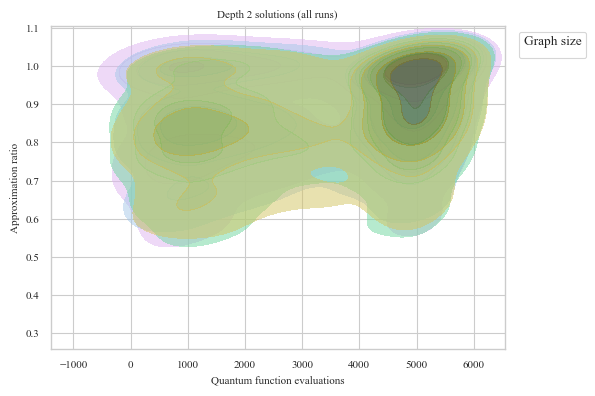

In [ ]:
subset_depth2 = df[df["depth"] == 4].copy()
subset_depth2 = subset_depth2.dropna(subset=["graph_size", "ratio", "quantum_func_evals"])

fig, ax = plt.subplots(figsize=(6, 4))

sns.kdeplot(
    data=subset_depth2,
    x="quantum_func_evals",
    y="ratio",
    hue="graph_size",
    fill=True,
    common_norm=False,
    alpha=0.5,
    palette="viridis",
    thresh=0.05,
    levels=6,
    ax=ax
)

ax.set_title("Depth 2 solutions (all runs)")
ax.set_xlabel("Quantum function evaluations")
ax.set_ylabel("Approximation ratio")
ax.legend(title="Graph size", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### High-level comparisons between ma- and v-qaoa across different metric

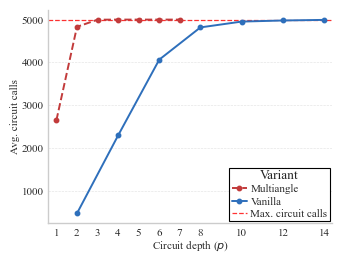

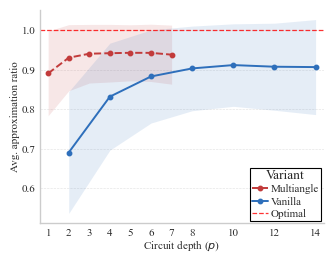

In [ ]:



def get_depth_analysis(df: pd.DataFrame) -> pd.DataFrame:
    """Compute depth-wise summary statistics for each QAOA variant."""
    df_analysis = df.copy()

    df_analysis["depth"] = pd.to_numeric(df_analysis["depth"], errors="coerce")
    df_analysis["quantum_func_evals"] = pd.to_numeric(
        df_analysis["quantum_func_evals"], errors="coerce"
    )
    df_analysis["ratio"] = pd.to_numeric(df_analysis["ratio"], errors="coerce")

    df_analysis = df_analysis.dropna(
        subset=["qaoa_variant", "depth", "quantum_func_evals", "ratio"]
    )

    summary = (
        df_analysis
        .groupby(["qaoa_variant", "depth"], as_index=False)
        .agg(
            avg_evals=("quantum_func_evals", "mean"),
            avg_ratio=("ratio", "mean"),
            std_ratio=("ratio", "std"),
        )
        .sort_values(["qaoa_variant", "depth"])
    )

    return summary


def plot_depth_progression_ieee(df: pd.DataFrame, save_images: bool = False) -> pd.DataFrame:
    """Plot and save only circuit calls and solution quality in IEEE style."""
    sns.set_theme(**PLOT_THEME)
    plt.rcParams.update(PLOT_RCPARAMS)

    summary = get_depth_analysis(df)
    all_depths = sorted(summary["depth"].unique())

    def style_axis(ax, ylabel: str):
        ax.set_xlabel("Circuit depth ($p$)", labelpad=1)
        ax.set_ylabel(ylabel, labelpad=1)
        ax.set_xticks(all_depths)
        ax.set_xticklabels([str(int(d)) for d in all_depths])
        ax.tick_params(axis="both", pad=1, length=2.5)
        ax.grid(axis="y", linestyle="--", linewidth=0.45, alpha=0.55)
        ax.grid(axis="x", visible=False)
        ax.margins(x=0.03, y=0.05)
        sns.despine(ax=ax)

    def add_legend(ax):
        ax.legend(
            title="Variant",
            loc="best",
            frameon=True,
            fancybox=False,
            framealpha=1.0,
            facecolor="white",
            edgecolor="black",
            borderpad=0.2,
            labelspacing=0.2,
            handlelength=1.4,
            handletextpad=0.3,
            borderaxespad=0.2,
        )

    # -------- Plot 1: Circuit calls --------
    fig, ax = plt.subplots(figsize=DEFUALT_COLUMN_FIGSIZE)

    for variant in QAOA_VARIANTS:
        cur = summary[summary["qaoa_variant"] == variant]
        if cur.empty:
            continue

        ax.plot(
            cur["depth"],
            cur["avg_evals"],
            marker="o",
            markersize=3.2,
            linewidth=1.4,
            linestyle=QAOA_VARIANT_LINESTYLES.get(variant, "-"),
            color=QAOA_VARIANT_COLORS[variant],
            label=QAOA_VARIANT_LABELS[variant],
            zorder=3,
        )
    ax.axhline(
        y=5000,
        color=OPTIMAL_LINE_COLOR,
        linestyle="--",
        linewidth=0.9,
        alpha=0.8,
        label="Max. circuit calls",
        zorder=2,
        )
    style_axis(ax, "Avg. circuit calls")
    add_legend(ax)

    fig.subplots_adjust(left=0.17, right=0.98, bottom=0.16, top=0.98)

    if save_images:
        fig.savefig(
            "pdf_images/overview_circuit_calls.pdf",
            bbox_inches="tight",
            pad_inches=0.01,
        )

    plt.show()

    # -------- Plot 2: Solution quality --------
    fig, ax = plt.subplots(figsize=DEFUALT_COLUMN_FIGSIZE)

    for variant in QAOA_VARIANTS:
        cur = summary[summary["qaoa_variant"] == variant]
        if cur.empty:
            continue

        ax.plot(
            cur["depth"],
            cur["avg_ratio"],
            marker="o",
            markersize=3.2,
            linewidth=1.4,
            linestyle=QAOA_VARIANT_LINESTYLES.get(variant, "-"),
            color=QAOA_VARIANT_COLORS[variant],
            label=QAOA_VARIANT_LABELS[variant],
            zorder=3,
        )

        # Optional uncertainty band
        ax.fill_between(
            cur["depth"],
            cur["avg_ratio"] - cur["std_ratio"].fillna(0),
            cur["avg_ratio"] + cur["std_ratio"].fillna(0),
            color=QAOA_VARIANT_COLORS[variant],
            alpha=0.12,
            linewidth=0,
            zorder=1,
        )

    ax.axhline(
        y=1.0,
        color=OPTIMAL_LINE_COLOR,
        linestyle="--",
        linewidth=0.9,
        alpha=0.8,
        label="Optimal",
        zorder=2,
    )

    style_axis(ax, "Avg. approximation ratio")
    add_legend(ax)

    fig.subplots_adjust(left=0.17, right=0.98, bottom=0.16, top=0.98)

    if save_images:
        fig.savefig(
            "pdf_images/overview_solution_quality.pdf",
            bbox_inches="tight",
            pad_inches=0.01,
        )

    plt.show()

    return summary


depth_summary = plot_depth_progression_ieee(df, save_images=save_images)

### Warm-start analysis

In [ ]:
df_ws = results[(results['warm_start'] == True ) &(results['lagrangian_multiplier'] == 2)].copy()


df_ws.describe()


,graph_size,depth,amount_shots,max_tol,lagrangian_multiplier,time_elapsed,quantum_func_evals,ratio,quantum_obj_value,classic_value,percent_measure_optimal,hamming_dist,hamming_obj_func,epsilon,final_expectation_value,graph_degree,final_params_len
count,7977.0,7977.000000,7977.0,7.977000e+03,7977.0,7977.000000,7977.000000,7977.000000,7977.000000,7977.000000,7977.000000,7977.000000,7977.000000,7.977000e+03,7977.000000,7977.0,7977.000000
mean,10.0,6.510092,1024.0,1.000000e-04,2.0,120.590978,4953.534161,0.887394,3.857485,3.355515,0.186298,3.004137,4.519461,3.000000e-01,4.491841,3.0,62.377460
std,0.0,3.500205,0.0,2.710675e-20,0.0,38.651791,315.443052,0.118997,0.784679,0.441713,0.336187,2.236765,0.945040,5.551463e-17,1.233400,0.0,42.502487
min,10.0,3.000000,1024.0,1.000000e-04,2.0,30.893820,977.000000,0.197749,2.312499,2.312499,0.000000,0.000000,2.312499,3.000000e-01,2.393810,3.0,20.000000
25%,10.0,3.000000,1024.0,1.000000e-04,2.0,80.054241,5000.000000,0.811745,3.342216,3.058387,0.000000,2.000000,3.755431,3.000000e-01,3.643376,3.0,20.000000
50%,10.0,10.000000,1024.0,1.000000e-04,2.0,101.150132,5000.000000,0.907136,3.755431,3.348049,0.000283,4.000000,4.636209,3.000000e-01,4.241932,3.0,20.000000
75%,10.0,10.000000,1024.0,1.000000e-04,2.0,158.942948,5000.000000,1.000000,4.262556,3.635567,0.143490,6.000000,5.229237,3.000000e-01,5.013173,3.0,105.000000
max,10.0,10.000000,1024.0,1.000000e-04,2.0,177.733137,5000.000000,1.000000,13.238289,4.494206,0.997504,6.000000,7.698893,3.000000e-01,10.306202,3.0,105.000000


7977


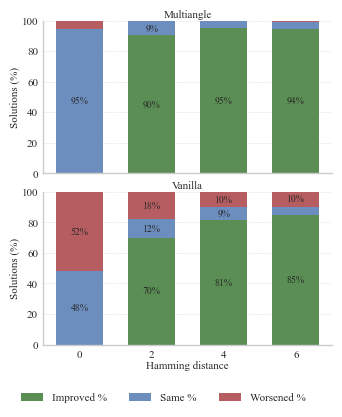

,qaoa_variant,Hamming Distance,Improved %,Same %,Worsened %,Count
0,multiangle,0.0,0.00,94.75,5.25,991
1,multiangle,2.0,90.30,9.19,0.51,990
2,multiangle,4.0,95.38,4.52,0.10,996
3,multiangle,6.0,94.40,4.90,0.70,1000
4,vanilla,0.0,0.00,48.20,51.80,1000
5,vanilla,2.0,69.80,12.40,17.80,1000
6,vanilla,4.0,81.30,8.80,9.90,1000
7,vanilla,6.0,84.70,5.60,9.70,1000


In [ ]:


def plot_warmstart_improvement_stats_ieee(df_ws, save_images=False):
    sns.set_theme(**PLOT_THEME)
    plt.rcParams.update(PLOT_RCPARAMS)

    improvement_rows = []

    ws_all = df_ws.copy()

    for qaoa_var in QAOA_VARIANTS:
        ws_filtered = ws_all[ws_all["qaoa_variant"] == qaoa_var]

        for hdist in sorted(ws_filtered["hamming_dist"].dropna().unique()):
            subset = ws_filtered[ws_filtered["hamming_dist"] == hdist].copy()
            total = len(subset)

            if total == 0:
                continue

            subset["actual_improvement"] = (
                subset["hamming_obj_func"] - subset["quantum_obj_value"]
            )

            improved = (subset["actual_improvement"] > 1e-4).sum() / total * 100
            same = (subset["actual_improvement"].abs() <= 1e-4).sum() / total * 100
            worsened = (subset["actual_improvement"] < -1e-4).sum() / total * 100

            improvement_rows.append({
                "qaoa_variant": qaoa_var,
                "Hamming Distance": hdist,
                "Improved %": improved,
                "Same %": same,
                "Worsened %": worsened,
                "Count": total,
            })

    improvement_stats = pd.DataFrame(improvement_rows)

    # Remove Equal Superposition if present
    improvement_stats = improvement_stats[
        improvement_stats["Hamming Distance"] != "Equal Superposition"
    ].copy()

    # Keep numeric hamming distances in order if possible
    try:
        hamming_order = sorted(improvement_stats["Hamming Distance"].astype(float).unique())
        improvement_stats["Hamming Distance"] = improvement_stats["Hamming Distance"].astype(float)
        xlabels = [str(int(x)) if float(x).is_integer() else str(x) for x in hamming_order]
    except Exception:
        hamming_order = list(improvement_stats["Hamming Distance"].unique())
        xlabels = [str(x) for x in hamming_order]

    fig, axes = plt.subplots(
        2, 1,
        figsize=(DEFAULT_QAOA_PAIR_FIGSIZE[0] / 3.4, 4.0),
        sharex=True,
        sharey=True
    )

    result_order = ["Improved %", "Same %", "Worsened %"]

    for ax, variant in zip(axes, QAOA_VARIANTS):
        cur = improvement_stats[improvement_stats["qaoa_variant"] == variant].copy()
        cur = cur.sort_values("Hamming Distance")

        x = np.arange(len(cur))
        bottom = np.zeros(len(cur))

        for result in result_order:
            vals = cur[result].values
            bars = ax.bar(
                x,
                vals,
                bottom=bottom,
                width=0.65,
                color=WARMSTART_RESULT_PALETTE[result],
                label=result,
                linewidth=0
            )

            # Only label reasonably large segments
            for xi, v, b in zip(x, vals, bottom):
                if v >= 8:
                    ax.text(
                        xi,
                        b + v / 2,
                        f"{v:.0f}%",
                        ha="center",
                        va="center",
                        fontsize=7
                    )

            bottom += vals

        ax.set_title(QAOA_VARIANT_LABELS[variant], pad=2)
        ax.set_ylim(0, 100)
        ax.set_ylabel("Solutions (%)", labelpad=1)
        ax.tick_params(axis="both", pad=1, length=2.5)
        ax.grid(axis="y", linestyle="--", linewidth=0.45, alpha=0.55)
        ax.grid(axis="x", visible=False)
        sns.despine(ax=ax)

    axes[-1].set_xlabel("Hamming distance", labelpad=1)
    axes[-1].set_xticks(np.arange(len(hamming_order)))
    axes[-1].set_xticklabels(xlabels)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc="lower center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, -0.01)
    )

    fig.subplots_adjust(
        left=0.16,
        right=0.98,
        top=0.97,
        bottom=0.16,
        hspace=0.12
    )

    if save_images:
        plt.savefig(
            "pdf_images/warm_start_improvement_stats_ieee.pdf",
            bbox_inches="tight",
            pad_inches=0.01
        )

    plt.show()

    return improvement_stats.round(2)

WARMSTART_RESULT_PALETTE = {
    "Improved %": "#5B8E55",
    "Same %": "#6C8EBF",
    "Worsened %": "#B55D60",
}





print(len(df_ws))
plot_warmstart_improvement_stats_ieee(df_ws, True)

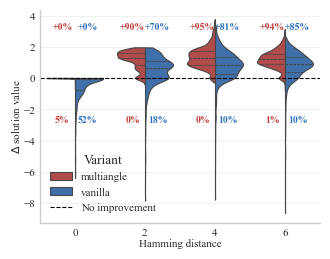

In [ ]:
def plot_ws_violin_ieee(df_ws, save_images=False):
    sns.set_theme(**PLOT_THEME)
    plt.rcParams.update(PLOT_RCPARAMS)

    df_plot = df_ws.copy()
    df_plot["improvement"] = df_plot["hamming_obj_func"] - df_plot["quantum_obj_value"]
    df_plot["hamming_dist"] = pd.to_numeric(df_plot["hamming_dist"], errors="coerce")

    df_plot = df_plot.dropna(
        subset=["qaoa_variant", "hamming_dist", "improvement"]
    )

    # Per-variant, per-Hamming-distance improvement statistics
    stats = (
        df_plot
        .groupby(["hamming_dist", "qaoa_variant"])["improvement"]
        .agg(
            Improved=lambda x: (x > 1e-4).mean() * 100,
            Worse=lambda x: (x < -1e-4).mean() * 100,
            Same=lambda x: (abs(x) <= 1e-4).mean() * 100,
        )
        .round(1)
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=DEFUALT_COLUMN_FIGSIZE)

    sns.violinplot(
        data=df_plot,
        x="hamming_dist",
        y="improvement",
        hue="qaoa_variant",
        palette=QAOA_VARIANT_COLORS,
        split=True,
        inner="quartile",
        cut=0,
        linewidth=0.8,
        density_norm="width",
        common_norm=False,
        ax=ax
    )

    ax.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=0.8,
        label="No improvement"
    )

    # Remove seaborn legend if desired
    ax.legend(
        title="Variant",
        loc="lower left",
        frameon=False
    )

    ax.set_xlabel("Hamming distance", labelpad=1)
    ax.set_ylabel(r"$\Delta$ solution value", labelpad=1)

    ax.tick_params(axis="both", pad=1, length=2.5)
    ax.grid(axis="y", linewidth=0.45, alpha=0.45)
    ax.grid(axis="x", visible=False)

    # Add per-violin annotations
    hamming_vals = sorted(df_plot["hamming_dist"].dropna().unique())

    ymin, ymax = ax.get_ylim()
    y_range = ymax - ymin

    top_y = ymax - 0.06 * y_range
    bottom_y = ymin + 0.06 * y_range

    # split=True puts variants on left/right halves of each x category
    variant_x_offsets = {
        "vanilla": 0.18,
        "multiangle": -0.18,
    }

    for i, hdist in enumerate(hamming_vals):
        for variant in QAOA_VARIANTS:
            row = stats[
                (stats["hamming_dist"] == hdist) &
                (stats["qaoa_variant"] == variant)
            ]

            if row.empty:
                continue

            improved = row["Improved"].iloc[0]
            worsened = row["Worse"].iloc[0]

            x_pos = i + variant_x_offsets.get(variant, 0)
            color = QAOA_VARIANT_COLORS[variant]

            # Improved above
            ax.text(
                x_pos,
                top_y,
                f"+{improved:.0f}%",
                ha="center",
                va="top",
                fontsize=7,
                color=color,
                fontweight="bold"
            )

            # Worsened below
            ax.text(
                x_pos,
                bottom_y + 5.5,
                f"{worsened:.0f}%",
                ha="center",
                va="bottom",
                fontsize=7,
                color=color,
                fontweight="bold"
            )


    sns.despine()

    fig.subplots_adjust(
        left=0.18,
        right=0.98,
        top=0.98,
        bottom=0.16
    )

    if save_images:
        fig.savefig(
            "pdf_images/WS_violin.pdf",
            bbox_inches="tight",
            pad_inches=0.01
        )

    plt.show()

plot_ws_violin_ieee(df_ws, save_images)

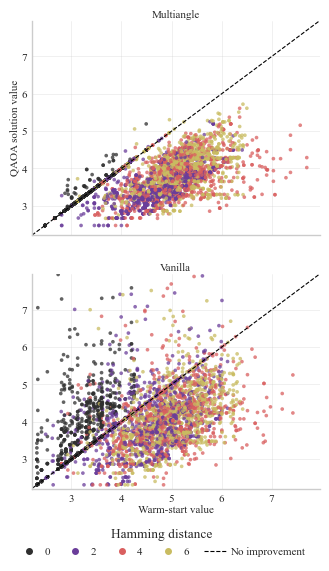

In [ ]:
from matplotlib.lines import Line2D

def plot_ws_scatter_ieee(df_ws, save_images=False):
    sns.set_theme(**PLOT_THEME)
    plt.rcParams.update(PLOT_RCPARAMS)

    df_plot = df_ws.copy()
    df_plot["hamming_obj_func"] = pd.to_numeric(df_plot["hamming_obj_func"], errors="coerce")
    df_plot["quantum_obj_value"] = pd.to_numeric(df_plot["quantum_obj_value"], errors="coerce")
    df_plot["hamming_dist"] = pd.to_numeric(df_plot["hamming_dist"], errors="coerce")

    df_plot = df_plot.dropna(
        subset=["qaoa_variant", "hamming_obj_func", "quantum_obj_value", "hamming_dist"]
    )

    hamming_palette = {
        0: "#2F2F2F",
        2: "#6A3D9A",
        4: "#D95F5F",
        6: "#C9BC61",
    }

    fig, axes = plt.subplots(
        2,1,
        figsize=(3.6,6),
        sharex=True,
        sharey=True
    )

    for ax, variant in zip(axes, QAOA_VARIANTS):
        variant_df = df_plot[df_plot["qaoa_variant"] == variant].copy()

        sns.scatterplot(
            data=variant_df,
            x="hamming_obj_func",
            y="quantum_obj_value",
            hue="hamming_dist",
            palette=hamming_palette,
            s=7,
            linewidth=0,
            alpha=0.75,
            legend=False,
            ax=ax,
        )

        lims = [
            min(ax.get_xlim()[0], ax.get_ylim()[0]),
            max(ax.get_xlim()[1], ax.get_ylim()[1]),
        ]

        ax.plot(
            lims,
            lims,
            color="black",
            linestyle="--",
            linewidth=0.8,
            label="No improvement",
            zorder=2,
        )

        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.set_aspect("auto")

        ax.set_title(QAOA_VARIANT_LABELS[variant], pad=2)
        ax.set_xlabel("Warm-start value", labelpad=1)
        ax.set_ylabel("QAOA solution value" if ax is axes[0] else "", labelpad=1)

        ax.tick_params(axis="both", pad=1, length=2.5)
        ax.grid(True, linewidth=0.45, alpha=0.45)

        sns.despine(ax=ax)

    # Shared legend
    hamming_handles = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            color=color,
            markersize=4,
            label=str(h)
        )
        for h, color in hamming_palette.items()
    ]

    line_handle = Line2D(
        [0], [0],
        color="black",
        linestyle="--",
        linewidth=0.8,
        label="No improvement"
    )

    legend_handles = hamming_handles + [line_handle]

    fig.legend(
        handles=legend_handles,
        title="Hamming distance",
        loc="lower center",
        ncol=5,
        frameon=False,
        bbox_to_anchor=(0.54, 0.03),
        columnspacing=1.3,
        handletextpad=0.4,
    )

    fig.subplots_adjust(
        left=0.18,
        right=0.98,
        top=0.94,
        bottom=0.16,
        hspace=0.18,
    )

    if save_images:
        fig.savefig(
            "pdf_images/WS_scatter.pdf",
            bbox_inches="tight",
            pad_inches=0.01
        )

    plt.show()

plot_ws_scatter_ieee(df_ws, save_images=save_images)

In [ ]:
print(len(results))
print(len(results))
params = results['final_params'].apply(lambda x: np.array(x['__ndarray__']))
print("All final params allclose:", np.allclose(params, params.iloc[0]))

93943
93943


ValueError: operands could not be broadcast together with shapes (93943,) (20,) 

C:\Users\torbjsme\AppData\Local\Temp\ipykernel_26160\813823738.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Hamming distance")


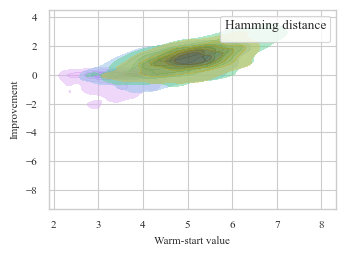

In [ ]:
# Assuming df_ws is already defined from previous cells
df_plot = df_ws.dropna(subset=["hamming_obj_func", "quantum_obj_value", "hamming_dist"]).copy()
df_plot["improvement"] = df_plot["hamming_obj_func"] - df_plot["quantum_obj_value"]

fig, ax = plt.subplots(figsize=DEFUALT_COLUMN_FIGSIZE)

sns.kdeplot(
    data=df_plot,
    x="hamming_obj_func",
    y="improvement",
    hue="hamming_dist",
    fill=True,
    common_norm=False,
    alpha=0.5,
    palette="viridis",
    thresh=0.05,
    levels=6,
    ax=ax,
)

ax.set_xlabel("Warm-start value")
ax.set_ylabel("Improvement")
ax.legend(title="Hamming distance")

plt.tight_layout()
if False:
    plt.savefig('pdf_images/average_improvement_vs_warmstart_density.pdf', bbox_inches='tight')

plt.show()

In [ ]:
solver_cache = {}

def get_solver(graph):
    key = graph["__bytes_b64__"]
    if key not in solver_cache:
        g = pickle.loads(base64.b64decode(key))
        solver_cache[key] = MinVertexCoverSolver(g, "mvc", lagrangian=2)
    return solver_cache[key]
def evaluate_hamming_string(graph, bitstring):
    solver = get_solver(graph)
    clean_bitstring = [round(x) for x in bitstring]
    return solver.evaluate_bitstring(clean_bitstring, mark_infeasible=True)



## Lagrange multipliers 

In [ ]:


df_lagrange = results[(results['warm_start']==False) &
                       (((results['qaoa_variant'] == 'vanilla') & (results['depth'] == 10) & (results['graph_size'] == 10))| 
                       ((results['qaoa_variant'] == 'multiangle') & (results['depth'] == 3)& (results['graph_size'] == 10)))]




print(df_lagrange['run_identifier'].value_counts()) #verify



run_identifier
vanilla10warm start: False hamming dist: 0 penalty factor: 1       1000
vanilla10warm start: False hamming dist: 0 penalty factor: 4       1000
vanilla10warm start: False hamming dist: 0 penalty factor: 10      1000
multiangle3warm start: False hamming dist: 0 penalty factor: 1     1000
multiangle3warm start: False hamming dist: 0 penalty factor: 4     1000
multiangle3warm start: False hamming dist: 0 penalty factor: 10    1000
multiangle3warm start: False hamming dist: 0 penalty factor: 2     1000
vanilla10warm start: False hamming dist: 0 penalty factor: 2       1000
Name: count, dtype: int64


Distribution of depth and variants in the dataset:
qaoa_variant  depth  lagrangian_multiplier  graph_size
multiangle    3      1                      10            1000
                     2                      10            1000
                     4                      10            1000
                     10                     10            1000
vanilla       10     1                      10            1000
                     2                      10            1000
                     4                      10            1000
                     10                     10            1000
dtype: int64


<Figure size 1200x600 with 0 Axes>

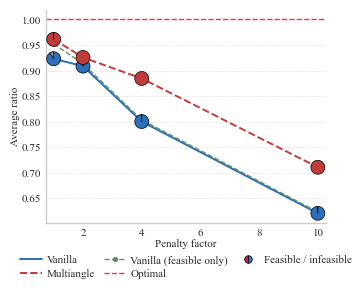

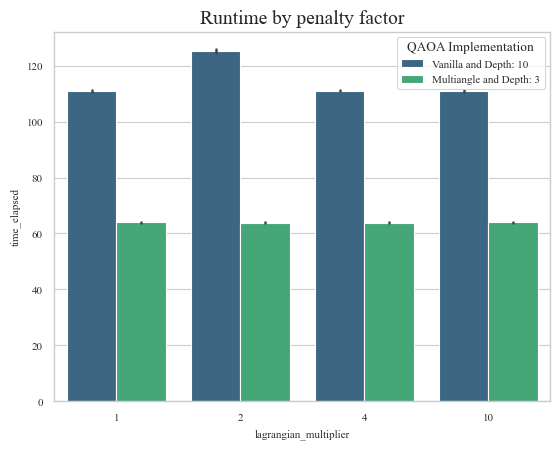

<Figure size 1200x600 with 0 Axes>

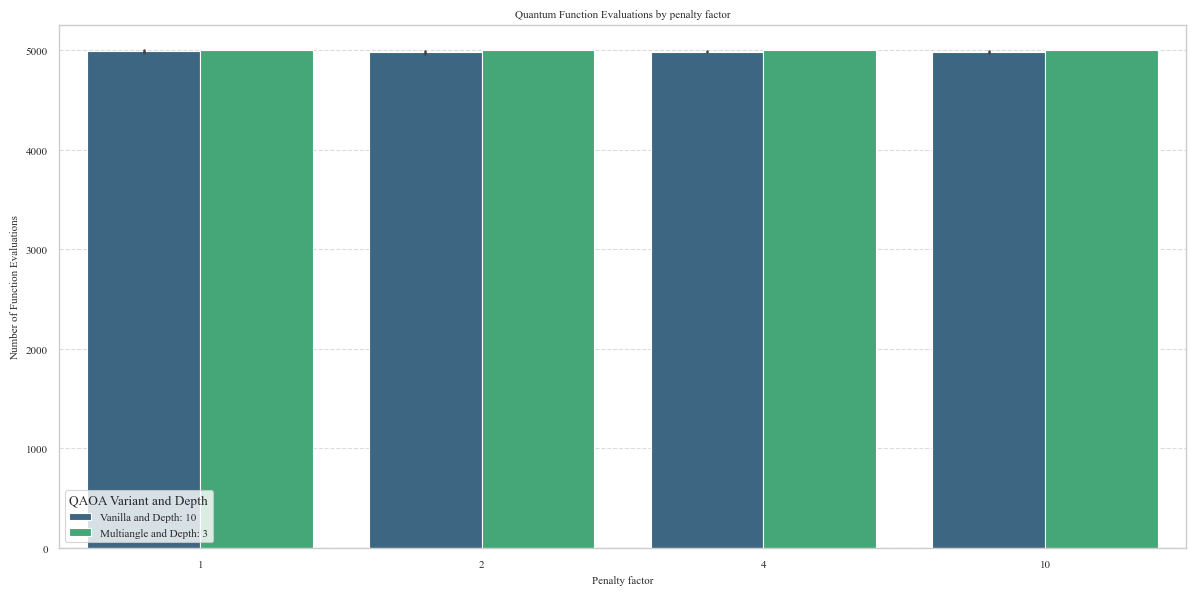

In [ ]:


# Create a visualization to analyze solution ratio by lagrangian multiplier and qaoa variant
plt.figure(figsize=(12, 6))

subset = df_lagrange.copy()
feasible_df = subset[subset['feasible']==True].copy()


# Let's analyze what depth & variants are available in our dataset
print("Distribution of depth and variants in the dataset:")
print(subset.groupby(['qaoa_variant', 'depth','lagrangian_multiplier','graph_size']).size())
# Create a new column that combines variant and depth for better labeling
subset['QAOA Implementation'] = subset.apply(lambda row: f"{row['qaoa_variant'].capitalize()} and Depth: {row['depth']}", axis=1)


from matplotlib.patches import Wedge
from matplotlib.offsetbox import DrawingArea, AnnotationBbox

plt.style.use("seaborn-v0_8-whitegrid")


from matplotlib.patches import Wedge
from matplotlib.offsetbox import DrawingArea, AnnotationBbox

from matplotlib.patches import Wedge
from matplotlib.offsetbox import DrawingArea, AnnotationBbox

def add_pie_marker(ax, x, y, infeasible_fraction, size=11,
                   colors=("tab:red", "tab:blue"),
                   edgecolor="black", linewidth=0.5, zorder=6):
    infeasible_fraction = float(np.clip(infeasible_fraction, 0.0, 1.0))
    feasible_fraction = 1.0 - infeasible_fraction

    da = DrawingArea(size, size, 0, 0)
    r = size / 2
    center = (r, r)

    if feasible_fraction > 0:
        da.add_artist(Wedge(center, r, 0, 360,
                            facecolor=colors[1],
                            edgecolor=edgecolor,
                            linewidth=linewidth))

    if infeasible_fraction > 0:
        da.add_artist(Wedge(center, r, 90, 90 + 360 * infeasible_fraction,
                            facecolor=colors[0],
                            edgecolor=edgecolor,
                            linewidth=linewidth))

    ab = AnnotationBbox(
        da, (x, y),
        frameon=False,
        box_alignment=(0.5, 0.5),
        zorder=zorder
    )
    ax.add_artist(ab)


def plot_lagrangian_ratio_with_infeasibility(df_lagrange, save_images=False):
    sns.set_theme(**PLOT_THEME)
    plt.rcParams.update(PLOT_RCPARAMS)

    df = df_lagrange.copy()

    required_cols = {
        "qaoa_variant",
        "lagrangian_multiplier",
        "ratio",
        "feasible",
    }
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df["lagrangian_multiplier"] = pd.to_numeric(df["lagrangian_multiplier"], errors="coerce")
    df["ratio"] = pd.to_numeric(df["ratio"], errors="coerce")
    df["feasible"] = df["feasible"].astype(bool)

    df = df.dropna(subset=["qaoa_variant", "lagrangian_multiplier", "ratio", "feasible"]).copy()

    summary_all = (
        df.groupby(["qaoa_variant", "lagrangian_multiplier"], as_index=False)
          .agg(
              mean_ratio_all=("ratio", "mean"),
              infeasible_fraction=("feasible", lambda s: 1 - s.mean()),
              n_runs=("feasible", "size"),
          )
    )

    vanilla_feasible = (
        df[(df["qaoa_variant"] == "vanilla") & (df["feasible"])]
        .groupby("lagrangian_multiplier", as_index=False)
        .agg(mean_ratio_feasible=("ratio", "mean"))
        .sort_values("lagrangian_multiplier")
    )

    colors = {
        "vanilla": QAOA_VARIANT_COLORS["vanilla"],
        "multiangle": QAOA_VARIANT_COLORS["multiangle"],
        "vanilla_feasible": "#5B8E55",
        "optimal": OPTIMAL_LINE_COLOR,
    }

    fig, ax = plt.subplots(figsize=DEFUALT_COLUMN_FIGSIZE)

    for variant in ["vanilla", "multiangle"]:
        cur = (
            summary_all[summary_all["qaoa_variant"] == variant]
            .sort_values("lagrangian_multiplier")
        )

        if cur.empty:
            continue

        ax.plot(
            cur["lagrangian_multiplier"],
            cur["mean_ratio_all"],
            linestyle=QAOA_VARIANT_LINESTYLES.get(variant, "-"),
            linewidth=1.4,
            color=colors[variant],
            label=f"{QAOA_VARIANT_LABELS[variant]}",
            zorder=2,
        )

        for _, row in cur.iterrows():
            if variant == "vanilla":
                pie_colors = ("#9E9E9E", colors["vanilla"])
            else:
                pie_colors = ("#9E9E9E", colors["multiangle"])

            add_pie_marker(
                ax=ax,
                x=row["lagrangian_multiplier"],
                y=row["mean_ratio_all"],
                infeasible_fraction=row["infeasible_fraction"],
                size=10,
                colors=pie_colors,
                zorder=5,
            )

    if not vanilla_feasible.empty:
        ax.plot(
            vanilla_feasible["lagrangian_multiplier"],
            vanilla_feasible["mean_ratio_feasible"],
            linestyle="--",
            linewidth=1.0,
            marker="o",
            markersize=2.8,
            color=colors["vanilla_feasible"],
            alpha=0.95,
            label="Vanilla (feasible only)",
            zorder=3,
        )

    ax.axhline(
        y=1,
        color=colors["optimal"],
        linestyle="--",
        linewidth=1.0,
        alpha=0.8,
        label="Optimal",
        zorder=1
    )

    ax.set_xlabel("Penalty factor", labelpad=1)
    ax.set_ylabel("Average ratio", labelpad=1)
    ax.tick_params(axis="both", pad=1, length=2.5)
    ax.grid(axis="y", linestyle="--", linewidth=0.45, alpha=0.55)
    ax.grid(axis="x", visible=False)
    ax.margins(x=0.03, y=0.05)

    composition_proxy = plt.Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor='crimson',
        markerfacecoloralt='royalblue',
        fillstyle='left',
        markeredgecolor='black',
        markeredgewidth=0.5,
        markersize=5.5,
        linestyle='None',
        label='Feasible / infeasible'
    )

    handles, labels = ax.get_legend_handles_labels()
    handles.append(composition_proxy)
    labels.append("Feasible / infeasible")

    ax.legend(
        handles, labels,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.12),
        ncol=3,
        frameon=False,
        columnspacing=0.8,
        handletextpad=0.4,
        borderpad=0.1,
        labelspacing=0.3
    )
    sns.despine()
    fig.subplots_adjust(left=0.18, right=0.98, bottom=0.16, top=0.98)

    if save_images:
        plt.savefig(
            "pdf_images/lagrangian_ratio_with_pies.pdf",
            bbox_inches="tight",
            pad_inches=0.01
        )

    plt.show()



plot_lagrangian_ratio_with_infeasibility(df_lagrange, True)

#
plt.title('Runtime by penalty factor', fontsize=14)
# Customize the plot

sns.barplot(
    palette='viridis',
    hue='QAOA Implementation',
    y='time_elapsed',
    x='lagrangian_multiplier', 
    data=subset, )


plt.figure(figsize=(12, 6)) # Create a figure for quantum function evaluations by Lagrangian multiplier
plt.figure(figsize=(12, 6))

# Create the boxplot to show distribution
sns.barplot(
    data=subset, 
    x='lagrangian_multiplier', 
    y='quantum_func_evals',
    hue='QAOA Implementation',
    palette='viridis'
)

# Customize the plot
plt.title('Quantum Function Evaluations by penalty factor')
plt.xlabel('Penalty factor')
plt.ylabel('Number of Function Evaluations')
plt.legend(title='QAOA Variant and Depth')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
if True:
    plt.savefig('pdf_images/lagrangian_ratio_analysis.pdf', bbox_inches='tight')
plt.show()

# Create a figure for runtime by Lagrangian multiplier

multiangle [ 1  2  4 10] [0.6 0.  0.  0. ]
vanilla [ 1  2  4 10] [9.5 0.9 1.  1.1]


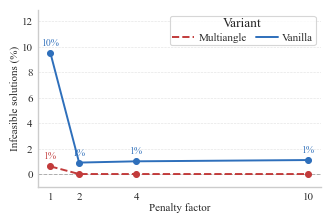

In [ ]:
def plot_lagrangian_comparison_ieee(df_lagrange, save_images=False):
    sns.set_theme(**PLOT_THEME)
    plt.rcParams.update(PLOT_RCPARAMS)

    df_analysis = df_lagrange.copy()

    grouped = (
        df_analysis
        .groupby(["qaoa_variant", "lagrangian_multiplier", "feasible"])
        .size()
        .reset_index(name="count")
    )

    pivot_df = grouped.pivot_table(
        index=["qaoa_variant", "lagrangian_multiplier"],
        columns="feasible",
        values="count",
        fill_value=0
    ).reset_index()

    pivot_df.rename(columns={True: "feasible", False: "infeasible"}, inplace=True)

    for col in ["feasible", "infeasible"]:
        if col not in pivot_df.columns:
            pivot_df[col] = 0

    pivot_df["total"] = pivot_df["feasible"] + pivot_df["infeasible"]
    pivot_df["feasible_pct"] = pivot_df["feasible"] / pivot_df["total"] * 100
    pivot_df["infeasible_pct"] = pivot_df["infeasible"] / pivot_df["total"] * 100

    pivot_df["qaoa_variant"] = pd.Categorical(
        pivot_df["qaoa_variant"],
        categories=QAOA_VARIANTS,
        ordered=True
    )
    pivot_df = pivot_df.sort_values(
        ["qaoa_variant", "lagrangian_multiplier"]
    ).reset_index(drop=True)

    colors = QAOA_VARIANT_COLORS
    labels = QAOA_VARIANT_LABELS

    fig, ax = plt.subplots(figsize=DEFUALT_COLUMN_FIGSIZE)
    fig.subplots_adjust(left=0.17, right=0.98, bottom=0.30, top=0.98)

    for variant in QAOA_VARIANTS:
        df_var = pivot_df[pivot_df["qaoa_variant"] == variant].copy()
        x = df_var["lagrangian_multiplier"].values
        y = df_var["infeasible_pct"].values
        print(variant , x ,y)
        color = colors[variant]
        linestyle = QAOA_VARIANT_LINESTYLES.get(variant, "-")

        ax.plot(
            x, y,
            color=color,
            linestyle=linestyle,
            linewidth=1.4,
            label=labels[variant],
            zorder=3
        )

        ax.scatter(
            x, y,
            color=color,
            s=18,
            zorder=5
        )

        for xi, yi in zip(x, y):
            if yi > 0:
                ax.text(
                    xi, yi + 0.4,
                    f"{yi:.0f}%",
                    ha="center",
                    va="bottom",
                    fontsize=7,
                    color=color
                )

    ax.axhline(0, color="gray", linewidth=0.7, linestyle="--", alpha=0.6)

    ax.set_xlabel("Penalty factor", labelpad=1)
    ax.set_ylabel("Infeasible solutions (%)", labelpad=1)

    all_pf = sorted(pivot_df["lagrangian_multiplier"].unique())
    ax.set_xticks(all_pf)
    ax.set_xticklabels([str(int(d)) if float(d).is_integer() else str(d) for d in all_pf])

    ax.set_ylim(-1, max(pivot_df["infeasible_pct"]) * 1.20 + 1.5)

    ax.tick_params(axis="both", pad=1, length=2.5)
    ax.grid(axis="y", linestyle="--", linewidth=0.45, alpha=0.55)
    ax.grid(axis="x", visible=False)

    handles, labs = ax.get_legend_handles_labels()
    seen = {}
    for h, l in zip(handles, labs):
        if l not in seen:
            seen[l] = h

    ax.legend(
        seen.values(),
        seen.keys(),
        loc="upper right",
        ncol=2,
        title="Variant",
        columnspacing=0.8,
        handletextpad=0.4,
        borderpad=0.2,
        labelspacing=0.3
    )

    sns.despine()

    if save_images:
        plt.savefig(
            "pdf_images/lagrangian_comparison.pdf",
            bbox_inches="tight",
            pad_inches=0.01
        )

    plt.show()
plot_lagrangian_comparison_ieee(df_lagrange, save_images)

### Combining Warm-Start and Lagrange 

In [ ]:
df_lagrange_ws = results[ (((results['qaoa_variant'] == 'vanilla') & (results['depth'] == 10) & (results['graph_size'] == 10))| 
                       ((results['qaoa_variant'] == 'multiangle') & (results['depth'] == 3)& (results['graph_size'] == 10)))].copy()



print(df_lagrange_ws['run_identifier'].value_counts()) #verify

run_identifier
vanilla10warm start: False hamming dist: 0 penalty factor: 1       1000
vanilla10warm start: False hamming dist: 0 penalty factor: 4       1000
vanilla10warm start: False hamming dist: 0 penalty factor: 10      1000
multiangle3warm start: False hamming dist: 0 penalty factor: 1     1000
multiangle3warm start: False hamming dist: 0 penalty factor: 4     1000
multiangle3warm start: False hamming dist: 0 penalty factor: 10    1000
multiangle3warm start: False hamming dist: 0 penalty factor: 2     1000
multiangle3warm start: True hamming dist: 0 penalty factor: 1      1000
multiangle3warm start: True hamming dist: 2 penalty factor: 1      1000
multiangle3warm start: True hamming dist: 4 penalty factor: 1      1000
multiangle3warm start: True hamming dist: 6 penalty factor: 2      1000
multiangle3warm start: True hamming dist: 0 penalty factor: 4      1000
vanilla10warm start: True hamming dist: 0 penalty factor: 1        1000
multiangle3warm start: True hamming dist: 6 penal

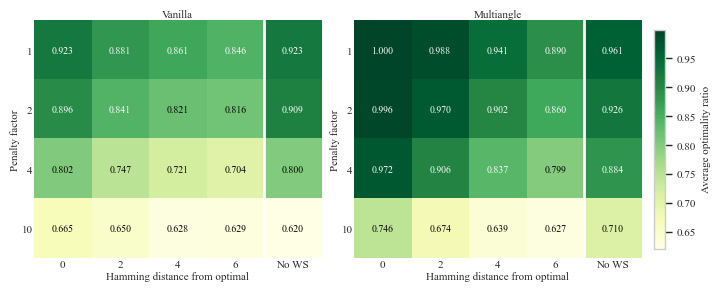

In [ ]:
import matplotlib.patheffects as path_effects
type_col = "qaoa_variant"

# Create display labels for x-axis
plot_df = df_lagrange_ws.copy()
plot_df["hamming_display"] = np.where(
    plot_df["warm_start"] == False,
    "No WS",
    plot_df["hamming_dist"].astype(str)
)

# Desired display order
hamming_order = ["0", "2", "4", "6", "No WS"]
lagrangian_order = [1, 2, 4, 10]

sns.set_theme(**PLOT_THEME)
plt.rcParams.update(PLOT_RCPARAMS)

def make_heatmap(ax, data, title, vmin=None, vmax=None, threshold=None):
    heatmap_data = (
        data.groupby(["lagrangian_multiplier", "hamming_display"])["ratio"]
            .mean()
            .unstack()
            .reindex(index=lagrangian_order, columns=hamming_order)
    )

    im = ax.imshow(
        heatmap_data,
        aspect="auto",
        cmap="YlGn",
        vmin=vmin,
        vmax=vmax
    )

    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(length=0, pad=1)

    ax.set_title(title, pad=2)
    ax.set_xlabel("Hamming distance from optimal", labelpad=1)
    ax.set_ylabel("Penalty factor", labelpad=1)

    ax.set_xticks(range(len(heatmap_data.columns)))
    ax.set_xticklabels(heatmap_data.columns)
    ax.set_yticks(range(len(heatmap_data.index)))
    ax.set_yticklabels(heatmap_data.index)

    # Visual divider before "No WS"
    if "No WS" in heatmap_data.columns:
        no_ws_idx = list(heatmap_data.columns).index("No WS")
        ax.axvline(no_ws_idx - 0.5, color="white", linewidth=2)



    for i in range(len(heatmap_data.index)):
        for j in range(len(heatmap_data.columns)):
            val = heatmap_data.iloc[i, j]
            if pd.notna(val):
                if val > threshold:
                    txt = ax.text(
                        j,
                        i,
                        f"{val:.3f}",
                        ha="center",
                        va="center",
                        fontsize=7,
                        color="white"
                    )
#                    txt.set_path_effects([
#                        path_effects.Stroke(linewidth=0.8, foreground="black"),
#                        path_effects.Normal()
#                    ])
                else:
                    ax.text(
                        j,
                        i,
                        f"{val:.3f}",
                        ha="center",
                        va="center",
                        fontsize=7,
                        color="black"
                    )

    return im

# Split by variant
vanilla_df = plot_df[plot_df[type_col].str.lower() == "vanilla"].copy()
multiangle_df = plot_df[plot_df[type_col].str.lower() == "multiangle"].copy()

# Shared color scale across both plots
all_means = (
    plot_df.groupby(["qaoa_variant", "lagrangian_multiplier", "hamming_display"])["ratio"]
           .mean()
)
vmin = all_means.min()
vmax = all_means.max()
global_threshold = all_means.mean()

fig, axes = plt.subplots(
    1, 2,
    figsize=(7.1, 2.8),
    constrained_layout=True
)

im1 = make_heatmap(
    axes[0],
    vanilla_df,
    QAOA_VARIANT_LABELS["vanilla"],
    vmin=vmin,
    vmax=vmax,
    threshold=global_threshold
)

im2 = make_heatmap(
    axes[1],
    multiangle_df,
    QAOA_VARIANT_LABELS["multiangle"],
    vmin=vmin,
    vmax=vmax,
    threshold=global_threshold
)

# One shared colorbar
cbar = fig.colorbar(im2, ax=axes, shrink=0.92, pad=0.02)
cbar.set_label("Average optimality ratio")

if save_images:
    plt.savefig(
        "pdf_images/variant_heatmap.pdf",
        bbox_inches="tight",
        pad_inches=0.01
    )

plt.show()